**Libraries**

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np
import pandas as pd
import cv2
import pydicom
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import imutils
import os
import re
import sys
from pathlib import Path
import joblib

**Defining file path and Cleaning up column names**

In [ ]:

CLINICAL_PATH = r"D:\Breast_Cancer_Dataset\Clinical_and_Other_Features.xlsx"

def auto_read_with_header_detection(path, lookahead=8):
    raw = pd.read_excel(path, header=None)

    # Detecting header with keywords
    key_re = re.compile(r"staging|tumor|nottingham|grade|\bT\b|\bN\b|\bM\b", re.I)
    header_row = None
    best_score = -1
    for r in range(min(lookahead, len(raw))):
        row_vals = raw.iloc[r].astype(str).fillna("")
        hits = sum(bool(key_re.search(v)) for v in row_vals)
        nonempty = (row_vals != "").sum()
        score = hits * 2 + nonempty
        if hits >= 1 and score > best_score:
            best_score = score
            header_row = r
    if header_row is None:
        header_row = 1 if len(raw) > 1 else 0

    df = pd.read_excel(path, header=header_row)

    # cleaning up column names
    df.columns = (
        df.columns.astype(str)
          .str.replace("\u00A0", " ", regex=False)
          .str.replace(r"\s+", " ", regex=True)
          .str.strip()
    )
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df = df.loc[:, ~df.columns.duplicated()]
    return df, header_row

clinical, used_header_row = auto_read_with_header_detection(CLINICAL_PATH)
print("Header row used:", used_header_row)
print("Shape:", clinical.shape)
display(clinical.head(2))

**Determining potential target features for cancer staging.
Using tumor staging features and Nottingham grade to locate relevant features**

In [4]:
def find_cols(df, patterns, flags=re.I):
    cols = []
    for c in df.columns.astype(str):
        if any(re.search(p, c, flags) for p in patterns):
            cols.append(c)
    return cols

label_T = find_cols(clinical, [r"staging.*tumor.*\[?t\]?", r"\bT\b"])
label_N = find_cols(clinical, [r"staging.*node.*\[?n\]?", r"\bN\b"])
label_M = find_cols(clinical, [r"staging.*metastasis.*\[?m\]?", r"\bM\b"])
label_NG = find_cols(clinical, [r"nottingham"])

print("T candidates:", label_T)
print("N candidates:", label_N)
print("M candidates:", label_M)
print("Nottingham candidates:", label_NG)

for cand in (label_T[:2] + label_N[:2] + label_M[:2] + label_NG[:2]):
    print(f"\n>> {cand}")
    display(clinical[cand].head(10))

T candidates: ['Staging(Tumor Size)# [T]', 'Pathologic response to Neoadjuvant therapy: Pathologic stage (T) following neoadjuvant therapy']
N candidates: ['Staging(Nodes)#(Nx replaced by -1)[N]', 'Pathologic response to Neoadjuvant therapy: Pathologic stage (N) following neoadjuvant therapy']
M candidates: ['Staging(Metastasis)#(Mx -replaced by -1)[M]', 'Pathologic response to Neoadjuvant therapy: Pathologic stage (M) following neoadjuvant therapy']
Nottingham candidates: ['Nottingham grade']

>> Staging(Tumor Size)# [T]


0    NaN
1    2.0
2    2.0
3    2.0
4    1.0
5    2.0
6    1.0
7    1.0
8    1.0
9    2.0
Name: Staging(Tumor Size)# [T], dtype: float64


>> Pathologic response to Neoadjuvant therapy: Pathologic stage (T) following neoadjuvant therapy


0    { -1 = TX;  0 = T0;  1 = T1;  2 = T2;  3 = T3;...
1                                                    1
2                                                  NaN
3                                                    1
4                                                  NaN
5                                                    0
6                                                  NaN
7                                                  NaN
8                                                  NaN
9                                                  NaN
Name: Pathologic response to Neoadjuvant therapy: Pathologic stage (T) following neoadjuvant therapy, dtype: object


>> Staging(Nodes)#(Nx replaced by -1)[N]


...

0    NaN
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Staging(Metastasis)#(Mx -replaced by -1)[M], dtype: float64


>> Pathologic response to Neoadjuvant therapy: Pathologic stage (M) following neoadjuvant therapy


0    { -1 = MX;  0 = M0;  1 = M1;  NA = not applica...
1                                                   -1
2                                                  NaN
3                                                   -1
4                                                  NaN
5                                                   -1
6                                                  NaN
7                                                  NaN
8                                                  NaN
9                                                  NaN
Name: Pathologic response to Neoadjuvant therapy: Pathologic stage (M) following neoadjuvant therapy, dtype: object


>> Nottingham grade


0    1=low 2=intermediate 3=high\n
1                                2
2                                3
3                              NaN
4                                2
5                                3
6                              NaN
7                                1
8                                2
9                                3
Name: Nottingham grade, dtype: object

**Manually selecting target feature for prediction from candidates in previous cell.
Selecting desired target column**

In [5]:
TARGET_COL = "Staging(Tumor Size)# [T]"

# Converting to numeric
clinical[TARGET_COL] = pd.to_numeric(clinical[TARGET_COL], errors="coerce")

# Filling in missing values using median
if clinical[TARGET_COL].isna().any():
    clinical[TARGET_COL] = clinical[TARGET_COL].fillna(clinical[TARGET_COL].median())

print(TARGET_COL, clinical[TARGET_COL].dtype)
display(clinical[[TARGET_COL]].head(10))

Staging(Tumor Size)# [T] float64


,Staging(Tumor Size)# [T]
0,2.0
1,2.0
2,2.0
3,2.0
4,1.0
5,2.0
6,1.0
7,1.0
8,1.0
9,2.0


**Removing leakage, ID, and technical features. Summarizing missing data.**

In [6]:
def drop_by_patterns(df, patterns, flags=re.I):
    cols = [c for c in df.columns if any(re.search(p, c, flags) for p in patterns)]
    return df.drop(columns=[c for c in cols if c in df.columns], errors="ignore"), cols

# Dropping potential data leakage features
leakage_patterns = [
    r"Neoadjuvant|Adjuvant|Therapy|Anti-?Her2|Endocrine",
    r"Pathologic response|Pathologic stage",
    r"Recurrence|death|last .*assessment|Age at last contact|Overall Near-?complete Response",
    r"Definitive Surgery|Surgery|Days to Surgery"
]
clinical_wo, dropped_leak = drop_by_patterns(clinical, leakage_patterns)

# Dropping unique identifiers or mapping keys
id_patterns = [r"^Accession|MRN|Study|Series|SOP|Filename"]
clinical_wo, dropped_id = drop_by_patterns(clinical_wo, id_patterns)

# Dropping MRI technical parameters such as manufacturer, etc.
tech_patterns = [
    r"Manufacturer|Model|Scan Options|Field Strength|TR|TE|Acquisition Matrix|Slice Thickness",
    r"Rows|Columns|Reconstruction Diameter|Flip Angle|FOV|Patient Position During MRI|Image Position of Patient|Contrast"
]
clinical_wo, dropped_tech = drop_by_patterns(clinical_wo, tech_patterns)

print(f"Dropped leakage cols: {len(dropped_leak)}")
print(f"Dropped id cols: {len(dropped_id)}")
print(f"Dropped tech cols: {len(dropped_tech)}")
print("Shape after drops:", clinical_wo.shape)

# Summary
missing_rate = clinical_wo.isnull().mean().sort_values(ascending=False)
print("Top-20 missing rate:")
display(missing_rate.head(20))


Dropped leakage cols: 26
Dropped id cols: 0
Dropped tech cols: 27
Shape after drops: (923, 34)
Top-20 missing rate:


Oncotype score                                 0.717226
Nottingham grade                               0.307692
Histologic type                                0.299025
Tumor Location                                 0.293608
Solid                                          0.279523
Mass Density                                   0.276273
Calcifications                                 0.247021
Shape                                          0.224269
Margin                                         0.216685
Margin.1                                       0.216685
Tumor Size (cm)                                0.189599
Shape.1                                        0.174431
Echogenicity                                   0.170098
Age at mammo (days)                            0.150596
Tumor Size (cm).1                              0.147346
Breast Density                                 0.123510
Staging(Nodes)#(Nx replaced by -1)[N]          0.027086
Tumor Grade                                    0

**Cleanup & Saving final CSV**

In [7]:
# Patient ID for future merging
patient_ids = clinical_wo["Patient ID"].astype(str).str.strip() if "Patient ID" in clinical_wo.columns else None

# target variable
y = pd.to_numeric(clinical_wo[TARGET_COL], errors="coerce")

# feature matrix X
X = clinical_wo.drop(columns=[TARGET_COL], errors="ignore")

# 🔹 Dropping features for modeling
for col in ["Patient ID", "Oncotype score"]:
    if col in X.columns:
        X = X.drop(columns=[col])

# splitting numeric vs categorical
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}")

# numerical
if num_cols:
    X[num_cols] = X[num_cols].apply(lambda s: s.fillna(s.mean()))

# categorical
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Y should have no missing values
if y.isna().any():
    y = y.fillna(y.median())

# target feature to int form
y = y.astype(int)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split result:", X_train.shape, X_test.shape)

# Saving dataset with Patient ID and Target
final_df = pd.concat([patient_ids.reset_index(drop=True),
                      X.reset_index(drop=True),
                      y.reset_index(drop=True)], axis=1)

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
final_path = OUT / "clinical_preprocessed_clean.csv"
# final_df.to_csv(final_path, index=False)

print("\n Saved cleaned dataset →", final_path)
display(final_df.head())

Numeric: 2, Categorical: 29
Split result: (738, 31) (185, 31)

 Saved cleaned dataset → outputs\clinical_preprocessed_clean.csv


,Patient ID,Menopause (at diagnosis),Race and Ethnicity,Metastatic at Presentation (Outside of Lymph Nodes),ER,PR,HER2,Mol Subtype,Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],...,Calcifications,Tumor Size (cm),Shape.1,Margin.1,Tumor Size (cm).1,Echogenicity,Solid,Known Ovarian Status,Number of Ovaries In Situ,Staging(Tumor Size)# [T]
0,nan,3,9,2,2,2,2,4,0.57461,-0.187636,...,15,33,9,13,47,17,1,2,4,2
1,Breast_MRI_001,0,2,0,0,0,1,2,1.00000,0.000000,...,13,33,7,10,47,14,1,1,0,2
2,Breast_MRI_002,0,2,0,0,0,0,3,0.00000,0.000000,...,13,33,7,10,47,14,1,0,3,2
3,Breast_MRI_003,1,1,0,1,1,0,0,1.00000,0.000000,...,0,33,7,10,47,14,1,0,3,2
4,Breast_MRI_004,1,1,0,1,1,0,0,0.00000,0.000000,...,13,33,7,10,47,14,1,0,3,1


**Import Imaging Features CSV**

In [8]:
df = pd.read_excel(r"D:\Breast_Cancer_Dataset\Imaging_Features.xlsx", header=0)
df.head()

,Patient ID,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,Breast_MRI_001,1.000000,0.120721,0.530395,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,3.380663,-0.025575,0.422391,0.171959,0.960359,0.996829,14.517894,20.347506,1.625870,11.406955
1,Breast_MRI_002,1.000000,0.129546,0.485217,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,3.444474,-0.036063,0.505652,0.177087,0.959067,0.996363,47.297950,83.909561,0.251498,5.659428
2,Breast_MRI_003,0.174775,0.062051,0.069910,0.132265,0.330662,0.349550,0.661324,0.699100,1.00000,...,3.478455,-0.043730,0.546674,0.170507,0.957527,0.995981,114.171582,129.252343,1.928743,11.554948
3,Breast_MRI_004,0.086546,0.045111,0.034619,0.051265,0.128162,0.173093,0.256325,0.346185,0.51265,...,3.389678,-0.017802,0.363818,0.177210,0.960705,0.996827,33.499175,69.164227,1.171314,8.493319
4,Breast_MRI_005,0.289669,0.052031,0.115868,0.378575,0.839984,0.579338,1.000000,0.958287,1.00000,...,4.009938,-0.049294,0.603426,0.117966,0.930624,0.989135,34.406635,26.951415,0.985464,4.331451


**FIll missing values and drop highly correlated features**

In [9]:
# Save Patient ID
patient_ids = df["Patient ID"]

# Drop Patient ID temporarily
df = df.drop(columns=["Patient ID"])

# Fill missing values with median
df = df.fillna(df.median(numeric_only=True))

# Drop highly correlated features (Pearson > 0.95)
corr = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df = df.drop(columns=to_drop)
print("Dropped", len(to_drop), "correlated features")

# Scale the data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Restore Patient ID
df_scaled.insert(0, "Patient ID", patient_ids)

Dropped 239 correlated features


**Merging Clinical and Imaging Datasets; Sunny**

In [10]:
# IMAGING_PATH = r"C:\Users\sunny\OneDrive - Cal State Fullerton\Documents\cpsc483\project\preprocessed_clean_image_features_with_median.csv"
# CLINICAL_PATH = r"C:\Users\sunny\OneDrive - Cal State Fullerton\Documents\cpsc483\project\clinical_preprocessed_clean.csv"
# MERGED_OUTPUT_PATH = r"C:\Users\sunny\OneDrive - Cal State Fullerton\Documents\cpsc483\project\final_merged_dataset.csv"

imaging_df = df_scaled
clinical_df = final_df

# Merging
merged_df = pd.merge(clinical_df, imaging_df, on="Patient ID", how="inner")

# Save and show
# merged.to_csv(MERGED_OUTPUT_PATH, index=False)
# print(f"Merged dataset saved to: {MERGED_OUTPUT_PATH}")
print("Shape:", merged_df.shape)
display(merged_df.head(3))

Shape: (922, 323)


,Patient ID,Menopause (at diagnosis),Race and Ethnicity,Metastatic at Presentation (Outside of Lymph Nodes),ER,PR,HER2,Mol Subtype,Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],...,WashinRate_map_Cluster_Prominence_tissue_PostCon,WashinRate_map_Cluster_Shade_tissue_PostCon,WashinRate_map_Energy_tissue_PostCon,WashinRate_map_Entropy_tissue_PostCon,WashinRate_map_Homogeneity1_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,Breast_MRI_001,0,2,0,0,0,1,2,1.0,0.0,...,-0.503248,-0.474442,0.592571,-0.570171,-0.264438,1.127476,-1.338198,-0.824595,0.033678,-0.081683
1,Breast_MRI_002,0,2,0,0,0,0,3,0.0,0.0,...,-0.685999,-0.970393,-1.072161,0.886720,-0.165372,0.635191,-0.494079,-0.598319,-1.291961,-0.081706
2,Breast_MRI_003,1,1,0,1,1,0,0,1.0,0.0,...,0.184038,0.333013,0.559093,-0.383067,-0.292492,0.275323,-0.078193,-0.136699,0.325812,-0.081682


**Drop target, filter highly correlated features**

In [11]:
# merged dataset/ change to your filepath if your using it on your pc)
# merged_df = pd.read_csv(r"C:\Users\sunny\OneDrive - Cal State Fullerton\Documents\cpsc483\project\final_merged_dataset.csv")

# save patientID
patient_ids = merged_df["Patient ID"]

# target column
target_column = "Staging(Tumor Size)# [T]"

# drop non-numeric + target
X = merged_df.drop(columns=[target_column])
y = merged_df[target_column]

# only numeric
X = X.select_dtypes(include=["number"])

# correlation filter
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X = X.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} highly correlated features")

Dropped 0 highly correlated features


**Scale Features**

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Classify feature importance utilizing random forest**

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)

importances = rf.feature_importances_
feature_ranks = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("All features ranked by importance:")
print(feature_ranks)

print(f"\nTotal features after dropping correlated ones: {X.shape[1]}")

# select top k features
top_k = 15
top_features = feature_ranks.head(top_k)['Feature'].tolist()
X_selected = pd.DataFrame(X_scaled, columns=X.columns)[top_features]

# reattach patient ID
X_selected.insert(0, "Patient ID", patient_ids)

print(f"\nTop {top_k} selected features:")
print(top_features)

All features ranked by importance:
                                               Feature  Importance
50                                  Volume_cu_mm_Tumor    0.023205
44                             TumorMajorAxisLength_mm    0.017809
189                        SER_Partial_tumor_vol_cu_mm    0.017673
227                  WashinRate_map_Homogeneity1_tumor    0.015323
232  WashinRate_map_information_measure_correlation...    0.015119
..                                                 ...         ...
24                                             Shape.1    0.000220
0                             Menopause (at diagnosis)    0.000184
20                                              Margin    0.000148
28                                               Solid    0.000067
21                                        Mass Density    0.000062

[321 rows x 2 columns]

Total features after dropping correlated ones: 321

Top 15 selected features:
['Volume_cu_mm_Tumor', 'TumorMajorAxisLength_mm', 'SER_Par

**Export as CSV**

In [14]:
# X_selected.to_csv("selected_features_only.csv", index=False)

**Import Merged CSV**

In [15]:
data = pd.read_csv(r'C:\Users\gabe7\Downloads\final_merged_dataset.csv')
data.head()

,Patient ID,Menopause (at diagnosis),Race and Ethnicity,Metastatic at Presentation (Outside of Lymph Nodes),ER,PR,HER2,Mol Subtype,Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],...,WashinRate_map_Cluster_Prominence_tissue_PostCon,WashinRate_map_Cluster_Shade_tissue_PostCon,WashinRate_map_Energy_tissue_PostCon,WashinRate_map_Entropy_tissue_PostCon,WashinRate_map_Homogeneity1_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,Breast_MRI_001,0,2,0,0,0,1,2,1.0,0.0,...,-0.503248,-0.474442,0.592571,-0.570171,-0.264438,1.127476,-1.338198,-0.824595,0.033678,-0.081683
1,Breast_MRI_002,0,2,0,0,0,0,3,0.0,0.0,...,-0.685999,-0.970393,-1.072161,0.886720,-0.165372,0.635191,-0.494079,-0.598319,-1.291961,-0.081706
2,Breast_MRI_003,1,1,0,1,1,0,0,1.0,0.0,...,0.184038,0.333013,0.559093,-0.383067,-0.292492,0.275323,-0.078193,-0.136699,0.325812,-0.081682
3,Breast_MRI_004,1,1,0,1,1,0,0,0.0,0.0,...,-0.584091,-0.564708,0.970854,-0.756188,-0.163010,1.492356,-1.932027,-0.693570,-0.404760,-0.081695
4,Breast_MRI_005,0,5,0,1,0,1,1,1.0,0.0,...,2.162493,2.311402,-0.862120,1.484125,-1.307421,0.014176,0.497173,-0.687306,-0.584020,-0.081712


**Overview**

In [16]:
print(f"Shape: {data.shape}")
print(f"Features: {data.shape[1]}")
print(f"Samples: {data.shape[0]}")
print(f"\nData types:\n{data.dtypes.value_counts()}")

Shape: (922, 323)
Features: 323
Samples: 922

Data types:
float64    292
int64       30
object       1
Name: count, dtype: int64


**Remove patient id**

In [106]:
# numerical_data = data.select_dtypes(include=["number"])
patient_ids = data["Patient ID"]

# Drop Patient ID temporarily
numerical_data = data.drop(columns=["Patient ID"])

**Identify Missing Values**

In [37]:
missing = (numerical_data.isnull().sum() / len(numerical_data)) * 100
missing = missing.sort_values(ascending=False)

# Show features with missing data
missing_features = missing[missing > 0]
print(f"\nFeatures with missing values: {len(missing_features)}")


Features with missing values: 0


**Identify features with low to no variance**

In [38]:
# Calculate variance for each feature
variances = numerical_data.var().sort_values()

# Find near-zero variance features
low_var_features = variances[variances < 0.01].index.tolist()
print(f"\nFeatures with very low variance (<0.01): {len(low_var_features)}")

# Check for constant features
constant_features = []
for col in numerical_data.columns:
    if numerical_data[col].nunique() == 1:
        constant_features.append(col)

print(f"\nConstant features (only 1 unique value): {len(constant_features)}")


Features with very low variance (<0.01): 0

Constant features (only 1 unique value): 0


In [39]:
numerical_data.columns

Index(['Menopause (at diagnosis)', 'Race and Ethnicity',
       'Metastatic at Presentation (Outside of Lymph Nodes)', 'ER', 'PR',
       'HER2', 'Mol Subtype', 'Staging(Nodes)#(Nx replaced by -1)[N]',
       'Staging(Metastasis)#(Mx -replaced by -1)[M]', 'Tumor Grade',
       ...
       'WashinRate_map_Cluster_Prominence_tissue_PostCon',
       'WashinRate_map_Cluster_Shade_tissue_PostCon',
       'WashinRate_map_Energy_tissue_PostCon',
       'WashinRate_map_Entropy_tissue_PostCon',
       'WashinRate_map_Homogeneity1_tissue_PostCon',
       'WashinRate_map_information_measure_correlation1_tissue_PostCon',
       'WashinRate_map_information_measure_correlation2_tissue_PostCon',
       'WashinRate_map_mean_tissue_PostCon',
       'WashinRate_map_skewness_tissue_PostCon',
       'WashinRate_map_kurtosis_tissue_PostCon'],
      dtype='object', length=322)

**Pearson Correlation**

In [40]:
correlation = numerical_data.corr(method='pearson')
correlation

,Menopause (at diagnosis),Race and Ethnicity,Metastatic at Presentation (Outside of Lymph Nodes),ER,PR,HER2,Mol Subtype,Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],Tumor Grade,...,WashinRate_map_Cluster_Prominence_tissue_PostCon,WashinRate_map_Cluster_Shade_tissue_PostCon,WashinRate_map_Energy_tissue_PostCon,WashinRate_map_Entropy_tissue_PostCon,WashinRate_map_Homogeneity1_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
Menopause (at diagnosis),1.000000,-0.054549,-0.031788,0.051375,0.011178,-0.058542,-0.081074,-0.084172,-0.041239,-0.057384,...,-0.211725,-0.185537,0.255197,-0.321114,0.260951,0.039653,-0.120649,-0.132877,0.202849,0.017151
Race and Ethnicity,-0.054549,1.000000,0.033332,-0.064855,-0.122510,0.078373,0.071212,0.065917,0.032486,0.056751,...,-0.002359,-0.019478,0.048160,-0.058856,0.019879,0.020672,-0.033208,-0.013937,0.054668,-0.015214
Metastatic at Presentation (Outside of Lymph Nodes),-0.031788,0.033332,1.000000,-0.008216,0.002485,0.079377,0.008188,0.170174,0.458905,0.080971,...,0.055760,0.053503,0.067593,-0.061029,0.054021,-0.035013,0.027265,-0.008724,0.093600,0.034705
ER,0.051375,-0.064855,-0.008216,1.000000,0.729166,-0.132104,-0.913575,-0.041345,0.035800,-0.181151,...,-0.047060,-0.038048,-0.004086,0.022446,-0.024546,0.089748,-0.065599,-0.059467,-0.030701,-0.012058
PR,0.011178,-0.122510,0.002485,0.729166,1.000000,-0.153168,-0.743588,-0.080079,0.069202,-0.183505,...,-0.074246,-0.058460,-0.010315,0.013510,-0.009737,0.063520,-0.044745,-0.059207,-0.032013,-0.032233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WashinRate_map_information_measure_correlation1_tissue_PostCon,0.039653,0.020672,-0.035013,0.089748,0.063520,0.002229,-0.070747,-0.078173,0.055667,-0.040680,...,-0.236165,-0.225122,0.039430,0.039519,-0.430286,1.000000,-0.939767,-0.114605,-0.210131,0.034674
WashinRate_map_information_measure_correlation2_tissue_PostCon,-0.120649,-0.033208,0.027265,-0.065599,-0.044745,-0.008602,0.044096,0.075663,-0.061244,0.023623,...,0.376658,0.366435,-0.248951,0.199536,0.196371,-0.939767,1.000000,0.217127,0.064761,-0.027952
WashinRate_map_mean_tissue_PostCon,-0.132877,-0.013937,-0.008724,-0.059467,-0.059207,0.012427,0.032202,0.106151,-0.027813,-0.001838,...,0.308635,0.231487,-0.193060,0.237131,-0.215475,-0.114605,0.217127,1.000000,0.000078,-0.007480
WashinRate_map_skewness_tissue_PostCon,0.202849,0.054668,0.093600,-0.030701,-0.032013,-0.022225,0.008367,0.059467,0.023100,0.055681,...,-0.095927,-0.019217,0.664926,-0.736129,0.697503,-0.210131,0.064761,0.000078,1.000000,0.009736


**Identify correlations close to 0**

In [41]:
target_features = [
    'Staging(Nodes)#(Nx replaced by -1)[N]',
    'Staging(Metastasis)#(Mx -replaced by -1)[M]'
]

corr_matrix = numerical_data.corr()

# store all selected features across all targets
selected_features_all = set()
for target in target_features:
    corr = corr_matrix[target].abs().sort_values(ascending=False)
    # Filter features with meaningful correlation (e.g., |r| > 0.1)
    selected_features = corr[corr > 0.08].index.tolist()
    # Add to global set
    selected_features_all.update(selected_features)
    print(f"\n📊 Top correlated features with {target}:")
    print(len(corr))
    print(corr.head(20))
print("\n✅ Total unique selected features across all targets:")
print(len(selected_features_all))
selected_features = list(selected_features_all)
selected_features


📊 Top correlated features with Staging(Nodes)#(Nx replaced by -1)[N]:
322
Staging(Nodes)#(Nx replaced by -1)[N]                    1.000000
Lymphadenopathy or Suspicious Nodes                      0.464134
Staging(Tumor Size)# [T]                                 0.354712
Inf_mea_of_corr1_Tumor                                   0.273209
WashinRate_map_Homogeneity1_tumor                        0.262153
TumorMajorAxisLength_mm                                  0.256036
WashinRate_map_difference_entropy_tumor                  0.244959
WashinRate_map_information_measure_correlation2_tumor    0.223818
Correlation1_Tumor                                       0.214208
WashinRate_map_information_measure_correlation1_tumor    0.210711
WashinRate_map_Contrast_tumor                            0.203601
SER_Partial_tumor_vol_cu_mm                              0.201449
Contrast_Tumor                                           0.201073
SER_Washout_tumor_vol_cu_mm                              0.197165
W

['WashinRate_map_Cluster_Prominence_tissue_PostCon',
 'WashinRate_map_information_measure_correlation2_tumor',
 'PE_map_Cluster_Prominence_tissue_T1',
 'Tumor Location',
 'PE_map_Entropy_tumor',
 'SER_map_Contrast_tumor',
 'Grouping_based_variance_of_washout_slope_3D_tissue_PostCon_Group_2',
 'Staging(Metastasis)#(Mx -replaced by -1)[M]',
 'Skin/Nipple Invovlement',
 'Cluster_Prominence_Tumor',
 'Staging(Nodes)#(Nx replaced by -1)[N]',
 'SER_Partial_tumor_vol_cu_mm',
 'Correlation1_Tumor',
 'WashinRate_map_Max_Probability_tumor',
 'PE_map_kurtosis_tumor',
 'F1_DT_T1NFS (T11=0.1,T12=0.8)',
 'PE_map_Autocorrelation_tumor',
 'Contrast_Tumor',
 'WashinRate_map_Autocorrelation_tissue_T1',
 'Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1',
 'SER_map_kurtosis_tumor',
 'Nottingham grade',
 'PR',
 'F1_DT_T1NFS (T11=0.05,T12=0.5)',
 'Shape.1',
 'SER_map_information_measure_correlation2_tumor',
 'WashinRate_map_information_measure_correlation1_tumor',
 'Peak_SER_tumor',
 'Was

**High correlation feature pairs**"

In [42]:
selected_data = numerical_data[selected_features]
# Calculate correlation matrix
corr_matrix = selected_data.corr().abs()

# Find pairs with correlation > 0.95 (excluding diagonal)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

# Check if any pairs were found
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(f"\nFound {len(high_corr_pairs)} highly correlated pairs (>0.95):")
    print(high_corr_df.sort_values('correlation', ascending=False))
else:
    print("\nNo highly correlated pairs found (>0.95)")
    print("Trying lower threshold (>0.90)...")
    
    # Try with lower threshold
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > 0.90:
                high_corr_pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs)
        print(f"\nFound {len(high_corr_pairs)} highly correlated pairs (>0.90):")
        print(high_corr_df.sort_values('correlation', ascending=False).head(20))
    else:
        print("No pairs found above 0.90 either")


No highly correlated pairs found (>0.95)
Trying lower threshold (>0.90)...

Found 16 highly correlated pairs (>0.90):
                                             feature1  \
6                       F1_DT_T1NFS (T11=0.1,T12=0.8)   
9                      SER_map_Entropy_tissue_PostCon   
2                              SER_map_Contrast_tumor   
10                              PE_map_Contrast_tumor   
13  Grouping_based_proportion_of_tumor_voxels_3D_t...   
1   WashinRate_map_information_measure_correlation...   
5                WashinRate_map_Max_Probability_tumor   
14                  WashinRate_map_Homogeneity1_tumor   
15                      WashinRate_map_mean_tissue_T1   
0    WashinRate_map_Cluster_Prominence_tissue_PostCon   
8                    WashinRate_map_std_dev_tissue_T1   
11                              PE_map_Contrast_tumor   
3                              SER_map_Contrast_tumor   
7            WashinRate_map_Autocorrelation_tissue_T1   
12      1st_DFT_CoeffMap_M

**Remove 1 feature out of the high correlation pairs**

In [43]:
features_to_drop = []
target_feature = 'Staging(Metastasis)#(Mx -replaced by -1)[M]'

for _, row in high_corr_df.iterrows():
    f1, f2 = row['feature1'], row['feature2']
    corr_f1 = corr_matrix.at[f1, target_feature]
    corr_f2 = corr_matrix.at[f2, target_feature]
    # Keep the feature with higher correlation to target
    if corr_f1 >= corr_f2:
        features_to_drop.append(f2)
    else:
        features_to_drop.append(f1)
# Remove duplicates
features_to_drop = list(set(features_to_drop))
features_to_drop

['WashinRate_map_Energy_tumor',
 'WashinRate_map_Autocorrelation_tissue_T1',
 'SER_map_Contrast_tumor',
 'Grouping_based_proportion_of_tumor_voxels_2D_tumorSlice_Group_3',
 'WashinRate_map_mean_tissue_PostCon',
 'WashinRate_map_std_dev_tissue_T1',
 'F1_DT_T1NFS (T11=0.1,T12=0.8)',
 'SER_map_Dissimilarity_tissue_PostCon',
 'WashinRate_map_Homogeneity1_tumor',
 'WashinRate_map_Cluster_Prominence_tissue_PostCon',
 'PE_map_Contrast_tumor',
 '1st_DFT_CoeffMap_Momment_Invariant_1_3D_tumor',
 'SER_Partial_tumor_vol_cu_mm',
 'WashinRate_map_information_measure_correlation2_tumor']

In [44]:
# Remove from selected features
reduced_features = [f for f in selected_features if f not in features_to_drop]
print(len(reduced_features))
reduced_features

88


['PE_map_Cluster_Prominence_tissue_T1',
 'Tumor Location',
 'PE_map_Entropy_tumor',
 'Grouping_based_variance_of_washout_slope_3D_tissue_PostCon_Group_2',
 'Staging(Metastasis)#(Mx -replaced by -1)[M]',
 'Skin/Nipple Invovlement',
 'Cluster_Prominence_Tumor',
 'Staging(Nodes)#(Nx replaced by -1)[N]',
 'Correlation1_Tumor',
 'WashinRate_map_Max_Probability_tumor',
 'PE_map_kurtosis_tumor',
 'PE_map_Autocorrelation_tumor',
 'Contrast_Tumor',
 'Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1',
 'SER_map_kurtosis_tumor',
 'Nottingham grade',
 'PR',
 'F1_DT_T1NFS (T11=0.05,T12=0.5)',
 'Shape.1',
 'SER_map_information_measure_correlation2_tumor',
 'WashinRate_map_information_measure_correlation1_tumor',
 'Peak_SER_tumor',
 'WashinRate_map_Correlation1_tumor',
 'Peak_PE_tumor',
 'SER_map_kurtosis_tissue_PostCon',
 'Median_solidity_Tumor',
 'Mean_norm_DLBP_max_timepoint_binsize_256_with_filling_Tumor',
 'Cluster_Shade_Tumor',
 'WashinRate_map_Cluster_Prominence_tumor',
 'Ec

**Correlation Matrix Visualization**

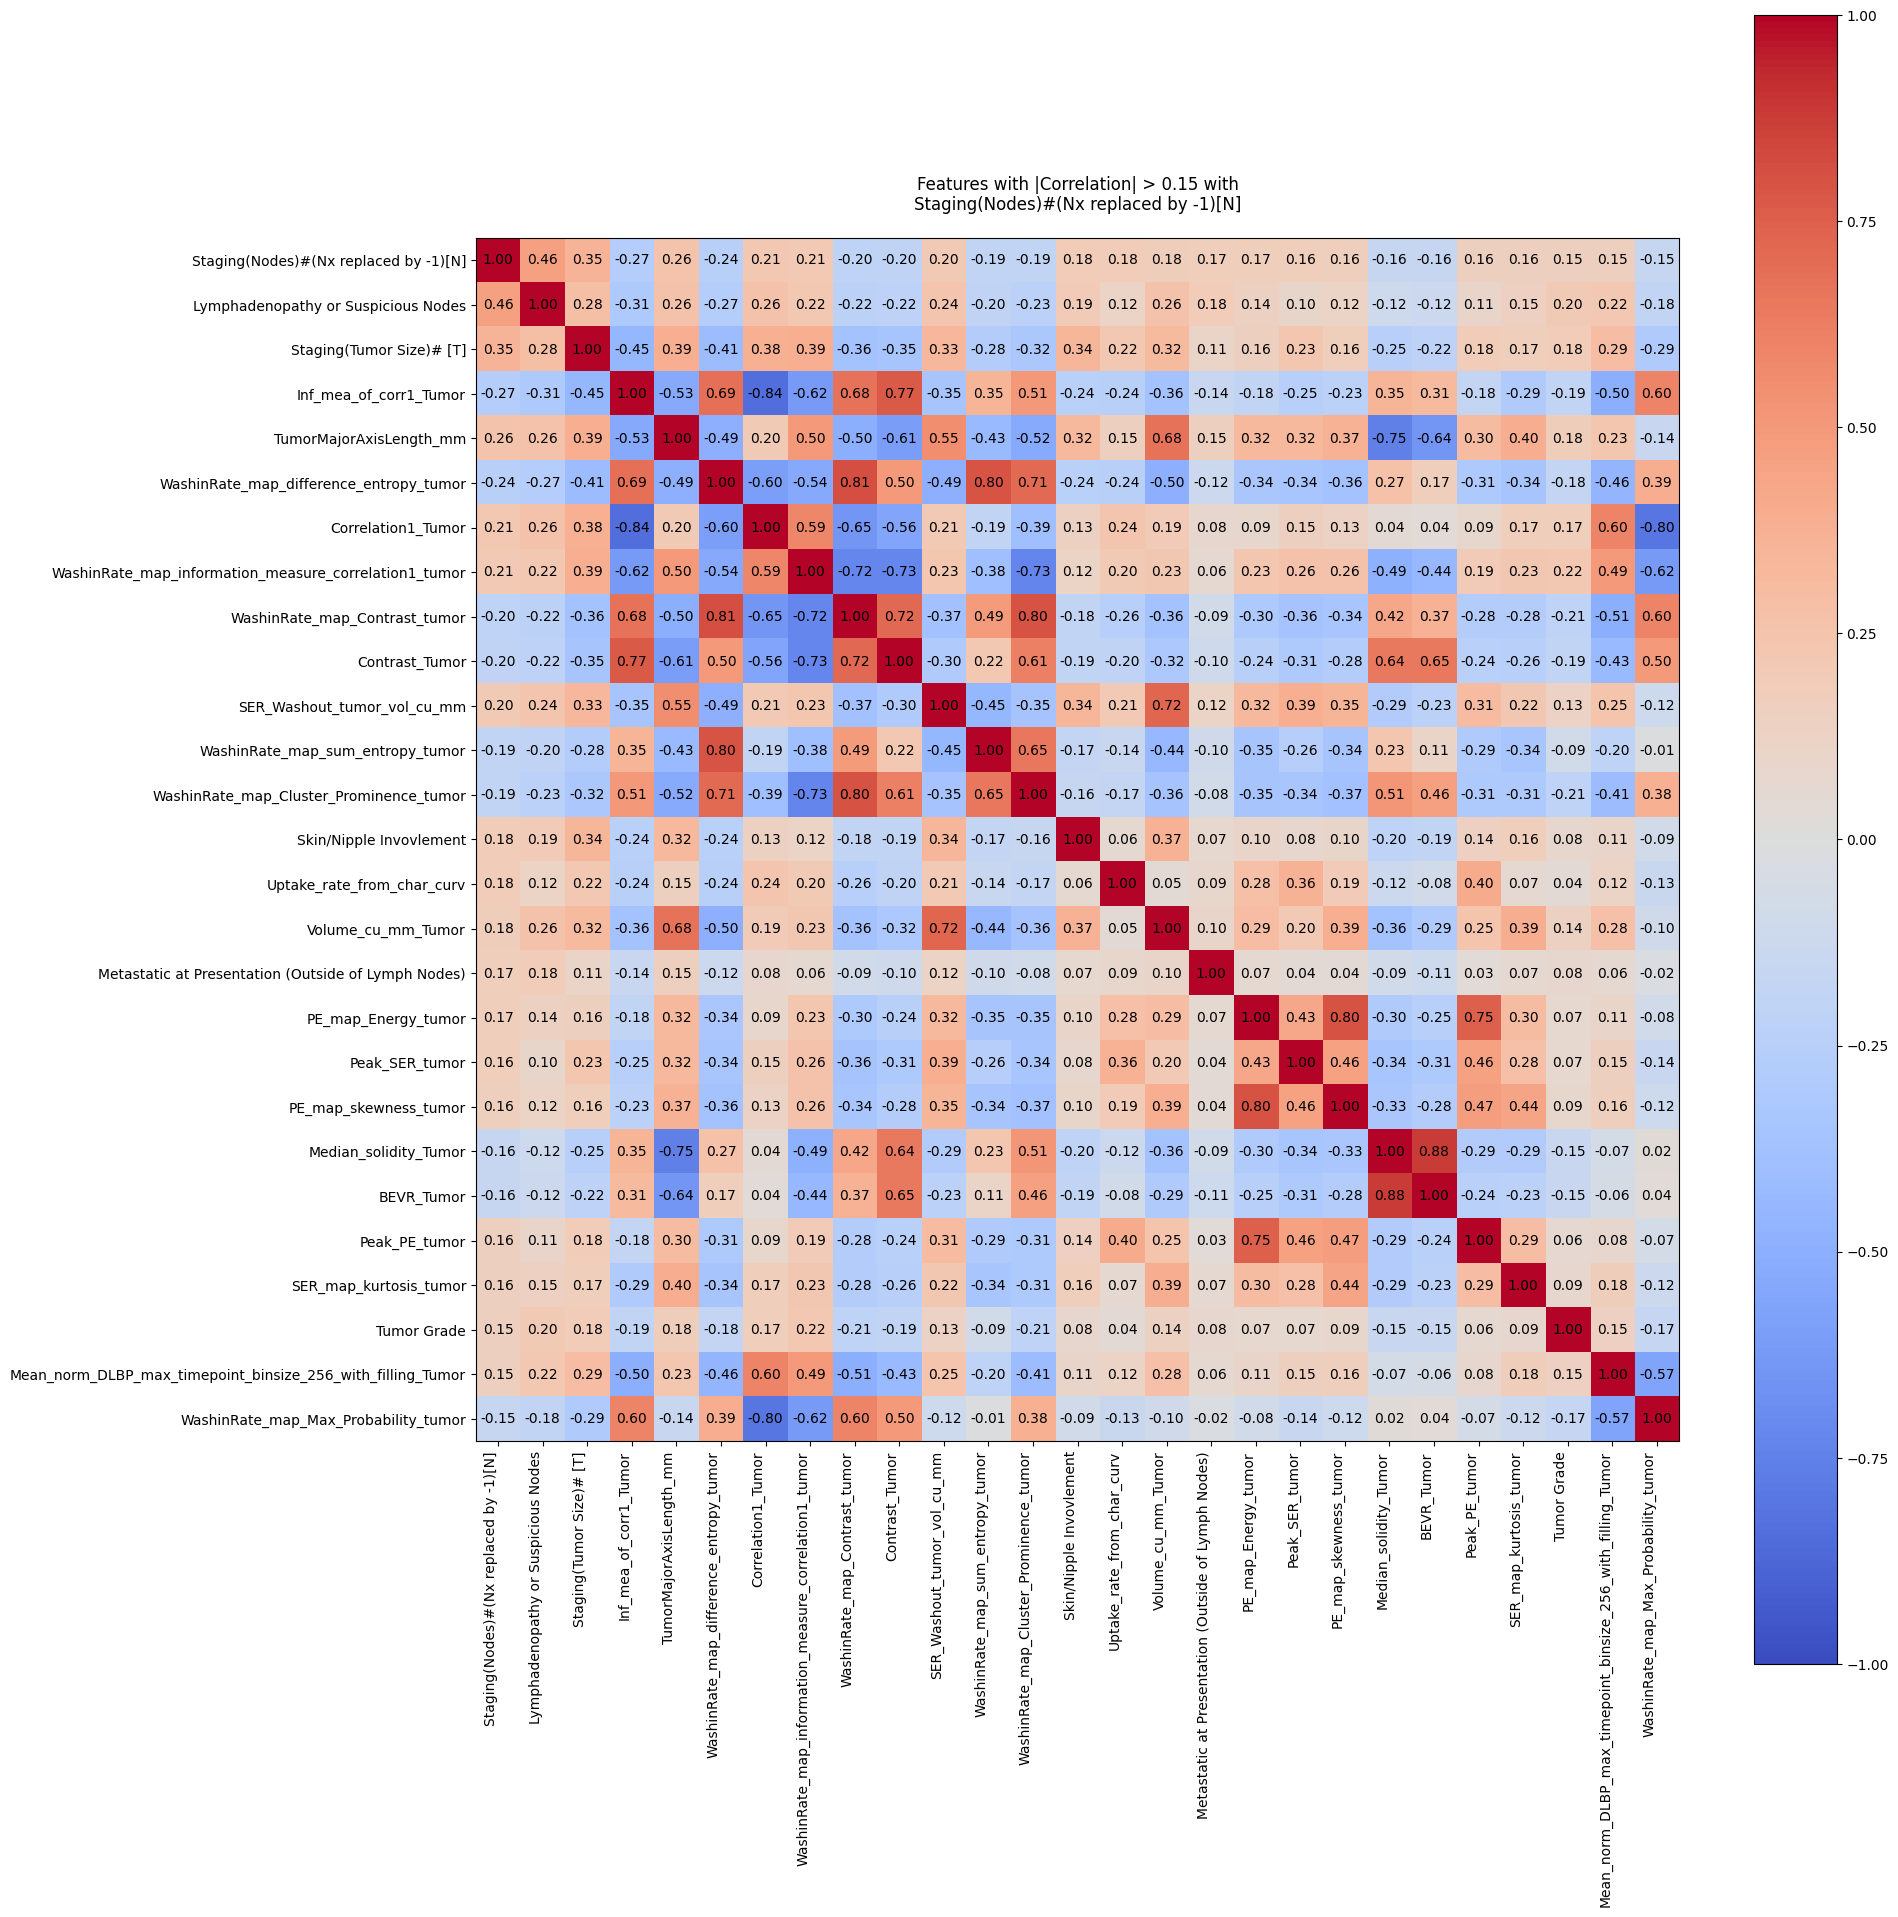

In [45]:
target = "Staging(Nodes)#(Nx replaced by -1)[N]"

# Compute correlation
corr_matrix = numerical_data[reduced_features].corr()
corr_abs = corr_matrix.abs()

# Filter features strongly correlated with target
relevant_features = corr_abs[corr_abs[target] > 0.15].index.tolist()

# Optional: sort by correlation strength (descending)
relevant_features = corr_abs[target].loc[relevant_features].sort_values(ascending=False).index.tolist()

# Subset matrix
subset_corr = corr_matrix.loc[relevant_features, relevant_features]

# Plot
fig, ax = plt.subplots(figsize=(20, 20))
im = ax.imshow(subset_corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(relevant_features)), labels=relevant_features, rotation=90, ha='right')
ax.set_yticks(np.arange(len(relevant_features)), labels=relevant_features)

# Annotate
for i in range(len(relevant_features)):
    for j in range(len(relevant_features)):
        ax.text(j, i, f"{subset_corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=ax)
plt.title(f'Features with |Correlation| > 0.15 with\n{target}', pad=20)
plt.tight_layout()
plt.show()

'WashinRate' appears multiple times. Identify all the columns containing Wash in Rate

In [46]:
washin_cols = [col for col in reduced_features if 'WashinRate' in col]
print(washin_cols)
print(f"Found {len(washin_cols)} Wash in Rate columns")

['WashinRate_map_Max_Probability_tumor', 'WashinRate_map_information_measure_correlation1_tumor', 'WashinRate_map_Correlation1_tumor', 'WashinRate_map_Cluster_Prominence_tumor', 'WashinRate_map_Autocorrelation_tumor', 'WashinRate_map_Cluster_Shade_tissue_PostCon', 'WashinRate_map_sum_entropy_tumor', 'WashinRate_map_Contrast_tumor', 'WashinRate_map_kurtosis_tumor', 'WashinRate_map_difference_entropy_tumor', 'WashinRate_map_mean_tissue_T1', 'WashinRate_map_Entropy_tumor', 'WashinRate_map_Autocorrelation_tissue_PostCon']
Found 13 Wash in Rate columns


In [47]:
SER_PE_cols = [col for col in reduced_features if 'SER_map' in col or 'PE_map' in col]
print(SER_PE_cols)
print(f"Found {len(SER_PE_cols)} SER, PE Maps columns")

['PE_map_Cluster_Prominence_tissue_T1', 'PE_map_Entropy_tumor', 'PE_map_kurtosis_tumor', 'PE_map_Autocorrelation_tumor', 'SER_map_kurtosis_tumor', 'SER_map_information_measure_correlation2_tumor', 'SER_map_kurtosis_tissue_PostCon', 'SER_map_mean_tumor', 'PE_map_skewness_tumor', 'SER_map_Entropy_tissue_PostCon', 'SER_map_Entropy_tumor', 'SER_map_Energy_tumor', 'SER_map_Dissimilarity_tumor', 'PE_map_Dissimilarity_tumor', 'PE_map_mean_tumor', 'PE_map_Cluster_Prominence_tumor', 'PE_map_Energy_tumor', 'PE_map_information_measure_correlation2_tumor', 'SER_map_Cluster_Prominence_tumor', 'PE_map_Contrast_tissue_T1']
Found 20 SER, PE Maps columns


We want to identify and remove the highest related 'WashinRate' features. Same with 'SER' and 'PE' Maps. All these features are likely to be highly related. PCA is ideal for large amounts of correlated features.

**Principle Component Analysis(PCA)** for PER and SE Maps

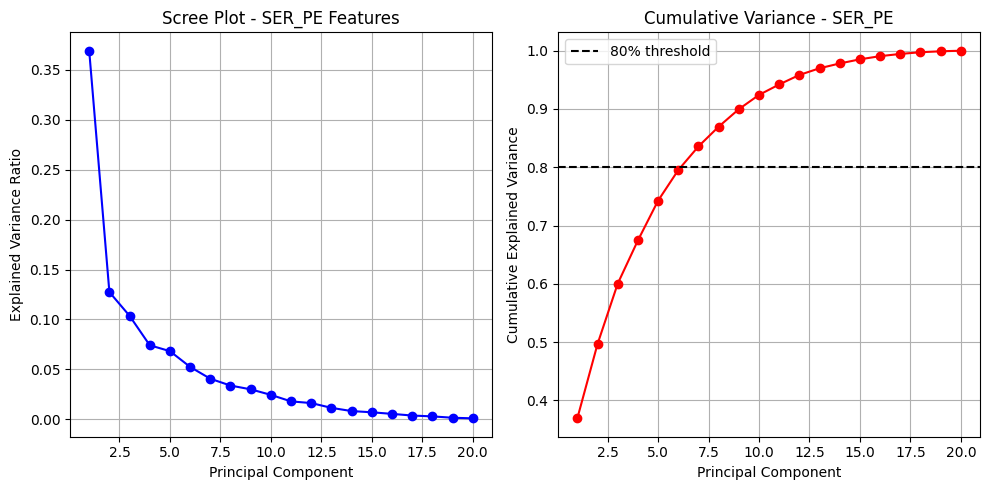


SER_PE PCA:
Number of components for 80% variance: 7
Original features: 20
Reduction: 13 features
Variance explained: 0.8358
Shape after SER_PE PCA: (922, 75)


In [87]:
numerical_data_reduced = numerical_data[reduced_features]
ser_pe = numerical_data[SER_PE_cols]  # Extract from original data

# Apply PCA
pca = PCA()
pca_features = pca.fit_transform(ser_pe)

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - SER_PE Features')
plt.grid(True)

plt.subplot(1, 2, 2)
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), cumsum_var, 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance - SER_PE')
plt.axhline(y=0.80, color='k', linestyle='--', label='80% threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Determine optimal number of components (80% variance)
n_components = np.argmax(cumsum_var >= 0.80) + 1
print(f"\nSER_PE PCA:")
print(f"Number of components for 80% variance: {n_components}")
print(f"Original features: {len(SER_PE_cols)}")
print(f"Reduction: {len(SER_PE_cols) - n_components} features")
print(f"Variance explained: {cumsum_var[n_components-1]:.4f}")

# Create PCA features
pca_optimal = PCA(n_components=n_components)
ser_pe_pca = pca_optimal.fit_transform(ser_pe)

# Add PCA components to dataframe
numerical_data_reduced = numerical_data_reduced.copy()
for i in range(n_components):
    numerical_data_reduced[f'ser_pe_PC{i+1}'] = ser_pe_pca[:, i]

# Drop original SER PE Map features
numerical_data_reduced = numerical_data_reduced.drop(columns=SER_PE_cols)

print(f"Shape after SER_PE PCA: {numerical_data_reduced.shape}")


**Principle Component Analysis(PCA)** for Wash in Rate

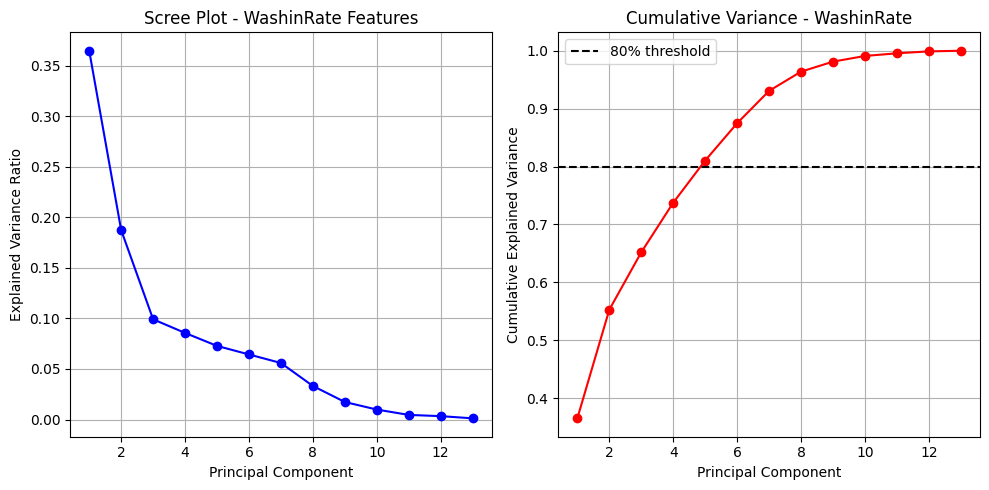


WashinRate PCA:
Number of components for 80% variance: 5
Original features: 13
Reduction: 8 features
Variance explained: 0.8103
Dropped 13 WashinRate columns

Final shape of numerical_data_reduced: (922, 67)
Total features: 67


In [88]:
washin = numerical_data[washin_cols]  # Extract from original data

# Apply PCA
pca = PCA()
pca_features = pca.fit_transform(washin)

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - WashinRate Features')
plt.grid(True)

plt.subplot(1, 2, 2)
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), cumsum_var, 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance - WashinRate')
plt.axhline(y=0.80, color='k', linestyle='--', label='80% threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Determine optimal number of components (80% variance)
n_components = np.argmax(cumsum_var >= 0.80) + 1
print(f"\nWashinRate PCA:")
print(f"Number of components for 80% variance: {n_components}")
print(f"Original features: {len(washin_cols)}")
print(f"Reduction: {len(washin_cols) - n_components} features")
print(f"Variance explained: {cumsum_var[n_components-1]:.4f}")

# Create PCA features
pca_optimal = PCA(n_components=n_components)
washin_pca = pca_optimal.fit_transform(washin)

# Add PCA components to dataframe
for i in range(n_components):
    numerical_data_reduced[f'WashinRate_PC{i+1}'] = washin_pca[:, i]

# Drop original WashinRate features
washin_cols_in_reduced = [col for col in washin_cols if col in numerical_data_reduced.columns]
if washin_cols_in_reduced:
    numerical_data_reduced = numerical_data_reduced.drop(columns=washin_cols_in_reduced)
    print(f"Dropped {len(washin_cols_in_reduced)} WashinRate columns")

print(f"\nFinal shape of numerical_data_reduced: {numerical_data_reduced.shape}")
print(f"Total features: {numerical_data_reduced.shape[1]}")

In [89]:
numerical_data_reduced

,Tumor Location,Grouping_based_variance_of_washout_slope_3D_tissue_PostCon_Group_2,Staging(Metastasis)#(Mx -replaced by -1)[M],Skin/Nipple Invovlement,Cluster_Prominence_Tumor,Staging(Nodes)#(Nx replaced by -1)[N],Correlation1_Tumor,Contrast_Tumor,Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1,Nottingham grade,...,ser_pe_PC3,ser_pe_PC4,ser_pe_PC5,ser_pe_PC6,ser_pe_PC7,WashinRate_PC1,WashinRate_PC2,WashinRate_PC3,WashinRate_PC4,WashinRate_PC5
0,0,-0.387083,0.0,0,-0.097689,1.0,0.607099,-0.113092,0.214135,2,...,-0.095813,-1.575226,0.182435,-0.915659,0.967382,-0.802195,0.127075,-0.892188,0.155314,-0.027625
1,0,-0.376334,0.0,0,-0.529238,0.0,-0.905026,-0.333360,-1.023768,3,...,0.237124,-1.013297,-0.608413,-0.044971,-0.768589,-1.029688,-0.710700,-1.558617,-0.446152,0.051461
2,1,0.122794,0.0,0,-1.175463,1.0,-1.429885,-0.579721,0.569044,2,...,-1.418389,0.597856,-0.329084,0.727162,-0.155033,0.508875,0.952658,-0.060066,0.219223,-1.700143
3,0,0.865065,0.0,0,0.943290,0.0,-0.467016,1.498831,-0.179665,2,...,0.615129,0.617780,-1.157558,-0.594001,0.294731,2.260507,0.631998,-0.543056,-0.638444,1.260510
4,1,-0.395070,0.0,0,-0.302734,1.0,0.134416,0.083114,-0.306068,3,...,-0.565132,-0.409745,-1.109704,-0.359884,0.564630,-0.467934,1.298645,0.656504,0.549843,-0.939036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,1,-0.383263,0.0,1,1.285573,2.0,1.518338,-0.526727,-0.542058,2,...,-0.921285,-0.501913,-0.262035,-0.070143,0.772135,-0.889887,1.734703,-1.216550,-0.711987,0.637032
918,1,-0.305842,0.0,0,-0.734591,0.0,-0.792370,-0.437896,-0.179665,2,...,0.848386,-0.955716,-1.207705,0.498294,-0.464466,2.163857,-0.144968,-1.277331,0.374875,-0.640106
919,1,-0.389351,0.0,0,2.022681,0.0,0.099061,1.559531,0.013098,2,...,2.445703,0.022803,0.548635,-2.037659,-0.412565,1.818362,0.427372,0.644208,-1.794426,2.914801
920,1,-0.354652,-1.0,0,0.875341,1.0,1.291129,-0.348792,-0.780331,2,...,-0.290428,-0.866021,-0.714529,0.759920,-0.297186,-1.629852,-0.158896,1.068538,-0.503796,1.359913


In [90]:
numerical_data_reduced.corr()

,Tumor Location,Grouping_based_variance_of_washout_slope_3D_tissue_PostCon_Group_2,Staging(Metastasis)#(Mx -replaced by -1)[M],Skin/Nipple Invovlement,Cluster_Prominence_Tumor,Staging(Nodes)#(Nx replaced by -1)[N],Correlation1_Tumor,Contrast_Tumor,Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1,Nottingham grade,...,ser_pe_PC3,ser_pe_PC4,ser_pe_PC5,ser_pe_PC6,ser_pe_PC7,WashinRate_PC1,WashinRate_PC2,WashinRate_PC3,WashinRate_PC4,WashinRate_PC5
Tumor Location,1.000000,-0.009862,0.118182,-0.034936,0.002560,0.047770,0.015975,-0.020281,0.001450,-0.020230,...,-0.011824,0.006907,0.006949,-0.004772,0.021773,-3.372657e-02,-1.074697e-02,2.257778e-02,8.775241e-02,3.915572e-04
Grouping_based_variance_of_washout_slope_3D_tissue_PostCon_Group_2,-0.009862,1.000000,-0.081189,-0.001869,-0.057564,-0.005104,0.015434,-0.067364,0.335753,-0.017637,...,-0.018365,-0.041851,0.244163,-0.055130,-0.199060,-9.007901e-02,-1.733516e-02,-2.314754e-03,9.736972e-02,-2.479946e-02
Staging(Metastasis)#(Mx -replaced by -1)[M],0.118182,-0.081189,1.000000,-0.058501,-0.010456,-0.033433,-0.024417,0.034225,-0.033236,0.009452,...,0.046103,0.042982,-0.018254,-0.011707,-0.007574,1.054926e-02,-6.489893e-02,-1.627464e-02,-3.734690e-02,-2.575422e-02
Skin/Nipple Invovlement,-0.034936,-0.001869,-0.058501,1.000000,-0.200339,0.180452,0.133300,-0.192327,0.008660,0.105829,...,0.071317,0.055383,0.022710,0.090116,-0.009709,-2.109616e-01,-5.284542e-02,2.512747e-02,-1.034827e-01,-6.327992e-02
Cluster_Prominence_Tumor,0.002560,-0.057564,-0.010456,-0.200339,1.000000,-0.142253,0.025980,0.672242,-0.126836,-0.117217,...,-0.035318,-0.080824,0.096409,-0.086776,0.101140,4.943976e-01,2.583553e-01,1.418251e-01,-2.818254e-02,5.083649e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WashinRate_PC1,-0.033727,-0.090079,0.010549,-0.210962,0.494398,-0.250168,-0.685464,0.724003,-0.045093,-0.242285,...,0.080325,-0.035576,-0.005872,-0.138935,-0.164648,1.000000e+00,2.469647e-16,1.347641e-16,3.206159e-16,1.677676e-16
WashinRate_PC2,-0.010747,-0.017335,-0.064899,-0.052845,0.258355,-0.007454,0.463687,-0.188881,0.007786,0.019798,...,-0.238437,0.003613,0.049903,0.161370,0.165102,2.469647e-16,1.000000e+00,1.969767e-16,6.400236e-16,3.077305e-16
WashinRate_PC3,0.022578,-0.002315,-0.016275,0.025127,0.141825,0.080803,0.018097,0.156080,0.004821,0.010625,...,-0.150829,0.050224,0.112011,0.314056,0.058063,1.347641e-16,1.969767e-16,1.000000e+00,-7.837779e-16,1.497591e-16
WashinRate_PC4,0.087752,0.097370,-0.037347,-0.103483,-0.028183,-0.082569,-0.145887,0.000480,-0.006355,0.003687,...,-0.132799,-0.154705,-0.066425,0.069845,-0.095265,3.206159e-16,6.400236e-16,-7.837779e-16,1.000000e+00,3.756977e-17


In [91]:
print(len(numerical_data_reduced.columns))
print(list(numerical_data_reduced.columns))

67
['Tumor Location', 'Grouping_based_variance_of_washout_slope_3D_tissue_PostCon_Group_2', 'Staging(Metastasis)#(Mx -replaced by -1)[M]', 'Skin/Nipple Invovlement', 'Cluster_Prominence_Tumor', 'Staging(Nodes)#(Nx replaced by -1)[N]', 'Correlation1_Tumor', 'Contrast_Tumor', 'Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1', 'Nottingham grade', 'PR', 'F1_DT_T1NFS (T11=0.05,T12=0.5)', 'Shape.1', 'Peak_SER_tumor', 'Peak_PE_tumor', 'Median_solidity_Tumor', 'Mean_norm_DLBP_max_timepoint_binsize_256_with_filling_Tumor', 'Cluster_Shade_Tumor', 'Echogenicity', 'F1_DT_T1NFS (T11=0.05,T12=0.8)', 'F1_DT_T1NFS (T11=0.2,T12=0.5)', 'F1_DT_POSTCON (T11=0.05,T12=0.8)', 'Change_in_variance_of_Uptake_Tumor', 'F1_DT_POSTCON (T11=0.05,T12=0.5)', 'MF_Tumor', 'Breast Density', 'Volume_cu_mm_Tumor', 'Lymphadenopathy or Suspicious Nodes', 'BEVR_Tumor', 'Variance_of_RGH_values_Tumor', 'Menopause (at diagnosis)', '2nd_DFT_CoeffMap_Momment_Invariant_1_3D_tumor', 'EnhancementClusterDiscontinui

In [92]:
feature_rankings = {}

for target in target_features:
    X = numerical_data_reduced.drop(columns=[target])
    y = numerical_data_reduced[target]
    model = RandomForestRegressor(random_state=42)

    model.fit(X, y)
    importances = model.feature_importances_

    # Rank features
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Store results
    feature_rankings[target] = importance_df

    print(f"\nTop 10 features for target '{target}':")
    print(importance_df.head(10).to_string(index=False))


Top 10 features for target 'Staging(Nodes)#(Nx replaced by -1)[N]':
                            Feature  Importance
Lymphadenopathy or Suspicious Nodes    0.215882
           Staging(Tumor Size)# [T]    0.038507
            TumorMajorAxisLength_mm    0.037720
                     WashinRate_PC2    0.031955
                     WashinRate_PC3    0.023930
                         ser_pe_PC4    0.023365
                         ser_pe_PC7    0.022785
                     Peak_SER_tumor    0.022036
                     WashinRate_PC1    0.019583
                         ser_pe_PC2    0.019054

Top 10 features for target 'Staging(Metastasis)#(Mx -replaced by -1)[M]':
                                                           Feature  Importance
               Metastatic at Presentation (Outside of Lymph Nodes)    0.206518
                     2nd_DFT_CoeffMap_Momment_Invariant_1_3D_tumor    0.031564
        Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_3    0.022715
Grouping_bas

In [114]:
final_features = [
    "Staging(Tumor Size)# [T]",
    "Staging(Nodes)#(Nx replaced by -1)[N]",
    "Staging(Metastasis)#(Mx -replaced by -1)[M]",
    "Age at mammo (days)",
    "Tumor Size (cm).1",
    "TumorMajorAxisLength_mm",
    "Tumor Location",
    "Menopause (at diagnosis)",
    "Volume_cu_mm_Tumor",
    "Lymphadenopathy or Suspicious Nodes",
    "Metastatic at Presentation (Outside of Lymph Nodes)",
    "Peak_SER_tumor",
    "Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_3",
    "WashinRate_PC2",
    "WashinRate_PC3",
    "ser_pe_PC4",
    "ser_pe_PC7",
    "Autocorrelation_Tumor",
    "Energy_Tumor",
    "Variance_of_RGH_values_Tumor",
    "Mean_norm_DLBP_max_timepoint_binsize_256_with_filling_Tumor",
    "Echogenicity"
]

final_features_df = numerical_data_reduced[final_features]

# Restore Patient ID
final_features_df.insert(0, "Patient ID", patient_ids)
final_features_df.head()
# Note: This DF is standardized

,Patient ID,Staging(Tumor Size)# [T],Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],Age at mammo (days),Tumor Size (cm).1,TumorMajorAxisLength_mm,Tumor Location,Menopause (at diagnosis),Volume_cu_mm_Tumor,...,Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_3,WashinRate_PC2,WashinRate_PC3,ser_pe_PC4,ser_pe_PC7,Autocorrelation_Tumor,Energy_Tumor,Variance_of_RGH_values_Tumor,Mean_norm_DLBP_max_timepoint_binsize_256_with_filling_Tumor,Echogenicity
0,Breast_MRI_001,2,1.0,0.0,53,47,-0.350045,0,0,-0.181871,...,-1.012349,0.127075,-0.892188,-1.575226,0.967382,0.370349,-0.710243,-0.473772,1.099950,14
1,Breast_MRI_002,2,0.0,0.0,53,47,-0.066026,0,0,-0.358187,...,0.047367,-0.710700,-1.558617,-1.013297,-0.768589,-0.827389,0.605332,-0.009675,-1.617884,14
2,Breast_MRI_003,2,1.0,0.0,15,47,0.153850,1,1,-0.309901,...,0.571278,0.952658,-0.060066,0.597856,-0.155033,-1.061083,0.926769,-0.363579,-1.370098,14
3,Breast_MRI_004,1,0.0,0.0,53,47,-0.833159,0,1,-0.390900,...,2.031160,0.631998,-0.543056,0.617780,0.294731,1.554014,-1.424826,0.654742,-0.672884,14
4,Breast_MRI_005,2,1.0,0.0,53,47,-0.159173,1,0,0.004069,...,0.243855,1.298645,0.656504,-0.409745,0.564630,0.264635,-0.818151,-0.428730,1.258657,14


**Export Submission CSV**

**Favorite Features:**

Age at Mammograph

Tumor Size (cm).1

TumorMajorAxisLength_mm

Tumor Location

Menopause (at diagnosis)

Volume_cu_mm_Tumor

Staging(Tumor Size)# [T]

Lymphadenopathy or Suspicious Nodes

Metastatic at Presentation (Outside of Lymph Nodes)

Peak_SER_tumor

Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_3

WashinRate_PC2

WashinRate_PC3

ser_pe_PC4

Autocorrelation_Tumor

Energy_Tumor

Variance_of_RGH_values_Tumor

Mean_norm_DLBP_max_timepoint_binsize_256_with_filling_Tumor

In [112]:
final_features_df.to_csv('D:/Breast_Cancer_Dataset/final_features.csv', index=False)

In [115]:
import os

# Check if the file exists
file_path = 'D:/Breast_Cancer_Dataset/final_features.csv'
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / 1024  # Size in KB
    print(f"✓ File saved successfully!")
    print(f"File size: {file_size:.2f} KB")
    print(f"Rows: {len(final_features_df)}")
    print(f"Columns: {len(final_features_df.columns)}")
else:
    print("✗ File not found")

✓ File saved successfully!
File size: 250.31 KB
Rows: 922
Columns: 23


Will incorporate different combinations of these features and choose the combination that shows strongest model performance. 

In [8]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

**Input Directory Format Example:**

Breast_Cancer_Dataset

------Duke-Breast-Cancer-MRI

-------------Breast_MRI_001

---------------------01-01-1990-NA-MRI BREAST BILATERAL WWO-97538

------------------------------------3.000000-ax dyn pre-93877

------------------------------------5.000000-ax dyn 1st pass-59529

------------------------------------8.000000-ax dyn 2nd pass-92755

------------------------------------11.000000-ax dyn 3rd pass-41458

------------------------------------14.000000-ax dyn 4th pass-47500

-------------------------------------------------1-001.dcm

-------------------------------------------------1-002.dcm

Image sequences should be of similar length.
Need to train/test split by patient AND seperate by sequence(Image sequence order matters). Each patient will have 5-7 seqeunces in the form of a 3D Tensor. Each patient will have a TNM label. Each patient will have tabular features. Label and features DO NOT differ by sequence. They differ by patient. 

In [3]:
favorite_features = ['Patient ID', 'Staging(Tumor Size)# [T]', 'Staging(Nodes)#(Nx replaced by -1)[N]', 'Staging(Metastasis)#(Mx -replaced by -1)[M]',
                     'Lymphadenopathy or Suspicious Nodes', 'Volume_cu_mm_Tumor', 'TumorMajorAxisLength_mm', 'Skin/Nipple Invovlement', 
                     'Pec/Chest Involvement']

In [4]:
imaging_features = pd.read_excel(r"C:\Users\gabe7\Downloads\Imaging_Features.xlsx", header=0)
imaging_features.columns

Index(['Patient ID', 'F1_DT_POSTCON (T11=0.05,T12=0.5)',
       'F1_DT_POSTCON (T11=0.05,T12=0.1)', 'F1_DT_POSTCON (T11=0.02,T12=0.5)',
       'F1_DT_POSTCON (T11=0.02,T12=0.8)', 'F1_DT_POSTCON (T11=0.05,T12=0.8)',
       'F1_DT_POSTCON (T11=0.1,T12=0.5)', 'F1_DT_POSTCON (T11=0.1,T12=0.8)',
       'F1_DT_POSTCON (T11=0.2,T12=0.5)', 'F1_DT_POSTCON (T11=0.2,T12=0.8)',
       ...
       'WashinRate_map_difference_entropy_tissue_PostCon',
       'WashinRate_map_information_measure_correlation1_tissue_PostCon',
       'WashinRate_map_information_measure_correlation2_tissue_PostCon',
       'WashinRate_map_inverse_difference_is_homom_tissue_PostCon',
       'WashinRate_map_inverse_difference_normalized_tissue_PostCon',
       'WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon',
       'WashinRate_map_mean_tissue_PostCon',
       'WashinRate_map_std_dev_tissue_PostCon',
       'WashinRate_map_skewness_tissue_PostCon',
       'WashinRate_map_kurtosis_tissue_PostCon'],
      dt

In [5]:
clinical_features = pd.read_excel(r"C:\Users\gabe7\Downloads\Clinical_and_Other_Features.xlsx", header=1)
clinical_features.columns

Index(['Patient ID', 'Days to MRI (From the Date of Diagnosis)',
       'Manufacturer', 'Manufacturer Model Name', 'Scan Options',
       'Field Strength (Tesla)', 'Patient Position During MRI',
       'Image Position of Patient', 'Contrast Agent',
       'Contrast Bolus Volume (mL)', 'TR (Repetition Time)', 'TE (Echo Time)',
       'Acquisition Matrix', 'Slice Thickness ', 'Rows', 'Columns',
       'Reconstruction Diameter ', 'Flip Angle \n',
       'FOV Computed (Field of View) in cm ', 'Date of Birth (Days)',
       'Menopause (at diagnosis)', 'Race and Ethnicity',
       'Metastatic at Presentation (Outside of Lymph Nodes)', 'ER', 'PR',
       'HER2', 'Mol Subtype', 'Oncotype score', 'Staging(Tumor Size)# [T]',
       'Staging(Nodes)#(Nx replaced by -1)[N]',
       'Staging(Metastasis)#(Mx -replaced by -1)[M]', 'Tumor Grade',
       'Unnamed: 32', 'Unnamed: 33', 'Nottingham grade', 'Histologic type',
       'Tumor Location', 'Position', 'Bilateral Information', 'Unnamed: 39',
     

In [6]:
merged_features = pd.merge(clinical_features, imaging_features, on='Patient ID', how='left')
merged_features

,Patient ID,Days to MRI (From the Date of Diagnosis),Manufacturer,Manufacturer Model Name,Scan Options,Field Strength (Tesla),Patient Position During MRI,Image Position of Patient,Contrast Agent,Contrast Bolus Volume (mL),...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,NaN,NaN,"GE MEDICAL SYSTEMS=0, MPTronic software=1, SIE...","Avanto=0, Optima MR450w=1, SIGNA EXCITE=2, SIG...","FAST_GEMS\SAT_GEMS\ACC_GEMS\PFP\FS=0,FAST_GEMS...","1.494=0,1.5=1,2.8936=2,3=3","FFP=0,HFP=1",NaN,"GADAVIST=0,MAGNEVIST=1,MMAGNEVIST=2,MULTIHANCE...","6=0,7=1,8=2,9=3,10=4,11=5,11.88=6,12=7,13=8,13...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Breast_MRI_001,6.0,2,0,5,1,0,-191.8003 X -176.1259 X 86.6065,1,15,...,3.380663,-0.025575,0.422391,0.171959,0.960359,0.996829,14.517894,20.347506,1.625870,11.406955
2,Breast_MRI_002,12.0,0,4,1,3,0,154.724 X 176.048 X 94.5771,1,NaN,...,3.444474,-0.036063,0.505652,0.177087,0.959067,0.996363,47.297950,83.909561,0.251498,5.659428
3,Breast_MRI_003,10.0,0,3,2,3,0,174.658 X 228.317 X 88.4878,1,NaN,...,3.478455,-0.043730,0.546674,0.170507,0.957527,0.995981,114.171582,129.252343,1.928743,11.554948
4,Breast_MRI_004,18.0,0,4,1,1,0,188.148 X 194.282 X 94.1832,1,NaN,...,3.389678,-0.017802,0.363818,0.177210,0.960705,0.996827,33.499175,69.164227,1.171314,8.493319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,Breast_MRI_918,6.0,0,4,1,1,0,179.537 X 165.877 X 100,4,NaN,...,3.116735,-0.050326,0.565456,0.223324,0.970250,0.997982,30.665570,65.018278,1.563114,12.928674
919,Breast_MRI_919,24.0,0,4,1,1,0,172.595 X 192.108 X 130.246,4,NaN,...,3.564943,-0.057053,0.620546,0.157804,0.953593,0.995567,19.556209,23.267576,0.463802,4.820925
920,Breast_MRI_920,21.0,2,0,5,1,1,-173.6078 X -147.4121 X 78.5315,3,5,...,3.369220,-0.050465,0.572790,0.178169,0.961318,0.996820,17.724748,18.299932,2.282520,13.460166
921,Breast_MRI_921,21.0,0,1,1,1,0,206.292 X 221.499 X 118.632,3,NaN,...,3.191276,-0.103623,0.750372,0.218098,0.968191,0.997618,149.643082,157.235282,1.318530,9.176372


In [7]:
final_features = merged_features[favorite_features]
final_features

,Patient ID,Staging(Tumor Size)# [T],Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],Lymphadenopathy or Suspicious Nodes,Volume_cu_mm_Tumor,TumorMajorAxisLength_mm,Skin/Nipple Invovlement,Pec/Chest Involvement
0,NaN,NaN,NaN,NaN,"{0 = no, 1 = yes}",NaN,NaN,"{0 = no, 1 = yes}","{0 = no, 1 = yes}"
1,Breast_MRI_001,2.0,1.0,0.0,0,5526.842083,27.569762,0,0
2,Breast_MRI_002,2.0,0.0,0.0,0,1279.434453,36.304675,0,0
3,Breast_MRI_003,2.0,1.0,0.0,1,2442.623934,43.066893,0,0
4,Breast_MRI_004,1.0,0.0,0.0,0,491.383512,12.711768,0,0
...,...,...,...,...,...,...,...,...,...
918,Breast_MRI_918,2.0,2.0,0.0,1,14826.965606,28.307300,1,0
919,Breast_MRI_919,1.0,0.0,0.0,0,874.207307,22.820165,0,0
920,Breast_MRI_920,1.0,0.0,0.0,0,603.619301,11.959180,0,0
921,Breast_MRI_921,2.0,1.0,-1.0,0,9800.326587,40.385788,0,0


In [8]:
final_features = final_features.iloc[1:].reset_index(drop=True)
final_features

,Patient ID,Staging(Tumor Size)# [T],Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],Lymphadenopathy or Suspicious Nodes,Volume_cu_mm_Tumor,TumorMajorAxisLength_mm,Skin/Nipple Invovlement,Pec/Chest Involvement
0,Breast_MRI_001,2.0,1.0,0.0,0,5526.842083,27.569762,0,0
1,Breast_MRI_002,2.0,0.0,0.0,0,1279.434453,36.304675,0,0
2,Breast_MRI_003,2.0,1.0,0.0,1,2442.623934,43.066893,0,0
3,Breast_MRI_004,1.0,0.0,0.0,0,491.383512,12.711768,0,0
4,Breast_MRI_005,2.0,1.0,0.0,1,10006.103516,33.439970,0,0
...,...,...,...,...,...,...,...,...,...
917,Breast_MRI_918,2.0,2.0,0.0,1,14826.965606,28.307300,1,0
918,Breast_MRI_919,1.0,0.0,0.0,0,874.207307,22.820165,0,0
919,Breast_MRI_920,1.0,0.0,0.0,0,603.619301,11.959180,0,0
920,Breast_MRI_921,2.0,1.0,-1.0,0,9800.326587,40.385788,0,0


In [9]:
final_features['Volume_cu_mm_Tumor'] = final_features['Volume_cu_mm_Tumor'].fillna(final_features['Volume_cu_mm_Tumor'].mean())
final_features['Staging(Tumor Size)# [T]'] = final_features['Staging(Tumor Size)# [T]'].fillna(1)
final_features['Staging(Nodes)#(Nx replaced by -1)[N]'] = final_features['Staging(Nodes)#(Nx replaced by -1)[N]'].fillna(0)
final_features.isna().sum()

Patient ID                                     0
Staging(Tumor Size)# [T]                       0
Staging(Nodes)#(Nx replaced by -1)[N]          0
Staging(Metastasis)#(Mx -replaced by -1)[M]    0
Lymphadenopathy or Suspicious Nodes            0
Volume_cu_mm_Tumor                             0
TumorMajorAxisLength_mm                        0
Skin/Nipple Invovlement                        0
Pec/Chest Involvement                          0
dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler
# Initialize scaler
scaler = StandardScaler()
# Columns you want to standardize
cols_to_scale = ['Volume_cu_mm_Tumor', 'TumorMajorAxisLength_mm']
# Apply scaling only to selected columns
final_features[cols_to_scale] = scaler.fit_transform(final_features[cols_to_scale])
# Check first 5 rows
final_features.head()

,Patient ID,Staging(Tumor Size)# [T],Staging(Nodes)#(Nx replaced by -1)[N],Staging(Metastasis)#(Mx -replaced by -1)[M],Lymphadenopathy or Suspicious Nodes,Volume_cu_mm_Tumor,TumorMajorAxisLength_mm,Skin/Nipple Invovlement,Pec/Chest Involvement
0,Breast_MRI_001,2.0,1.0,0.0,0,-0.182199,-0.350045,0,0
1,Breast_MRI_002,2.0,0.0,0.0,0,-0.358522,-0.066026,0,0
2,Breast_MRI_003,2.0,1.0,0.0,1,-0.310234,0.153850,0,0
3,Breast_MRI_004,1.0,0.0,0.0,0,-0.391237,-0.833159,0,0
4,Breast_MRI_005,2.0,1.0,0.0,1,0.003750,-0.159173,0,0


**Dataset Feature Loading**

In [11]:
def load_features(features_pd):
    tumor, node, metastasis = 'Staging(Tumor Size)# [T]', 'Staging(Nodes)#(Nx replaced by -1)[N]', 'Staging(Metastasis)#(Mx -replaced by -1)[M]'
    # Get patient ID
    patient_id = features_pd['Patient ID']
    # Get label columns
    t = features_pd[tumor]
    n = features_pd[node]
    m = features_pd[metastasis]
    # Drop label columns
    features = features_pd.drop([tumor, node, metastasis], axis=1)
    # Combine labels into one DataFrame
    labels = pd.DataFrame({
        'Patient ID': patient_id,
        'T': t,
        'N': n,
        'M': m
    })
    labels['T'] = labels['T'].round()
    labels['N'] = labels['N'].round()
    labels['M'] = labels['M'].round()
    return features, labels 

In [12]:
root_directory = r"C:\Users\gabe7\CSU Fullerton Dropbox\Gabriel Rodriguez\Breast_Cancer_Dataset"
feature_csv = "https://dl.dropboxusercontent.com/scl/fi/nxafq0q32lqbta8wuy8zc/final_features.csv?rlkey=6ll6olx5fig9io0v1l77ycvbr&st=qvvvyehy"
bb_dir = "https://dl.dropboxusercontent.com/scl/fi/rqcyed40xtibqr5z699et/Annotation_Boxes.xlsx?rlkey=hxj1xgnq8ic352po56rx10jy5&st=91xbap3h&dl=0"
bounding_boxes = pd.read_excel(bb_dir)
bounding_boxes.head()

,Patient ID,Start Row,End Row,Start Column,End Column,Start Slice,End Slice
0,Breast_MRI_001,234,271,308,341,89,112
1,Breast_MRI_002,251,294,108,136,59,72
2,Breast_MRI_003,351,412,82,139,96,108
3,Breast_MRI_004,262,280,193,204,86,95
4,Breast_MRI_005,188,213,138,178,76,122


In [14]:
# Load Feature DataFrames
features, labels = load_features(final_features)

**Create pandas dataframe for sequence folder paths.**

In [15]:
root_directory = r"C:\Users\gabe7\Downloads\Breast_MRI_Subset"
image_columns = ['Patient ID', 'Folder Path']
image_df = pd.DataFrame(columns=image_columns)
# 1 sequence folder in directory per patient
for sequence_folder in os.listdir(root_directory):
    sequence_path = os.path.join(root_directory, sequence_folder)
        # find subfolders
    subfolders = [
        f for f in os.listdir(sequence_path)
        if os.path.isdir(os.path.join(sequence_path, f))
    ]
    has_subfolders = len(subfolders) > 0
    if has_subfolders:
        for subfolder in subfolders:
            subfolder_path = os.path.join(sequence_path, subfolder)
            print(subfolder_path)
            # Each sequence folder contains about 50-200 DICOM images.
            # Create new row to append to image dataframe
            new_row = pd.DataFrame({'Patient ID': [sequence_folder],
                            'Folder Path': [subfolder_path]})
            # Add row
            image_df.loc[len(image_df)] = [sequence_folder, subfolder_path]
    else:
        new_row = pd.DataFrame({'Patient ID': [sequence_folder],
                            'Folder Path': [sequence_path]})
        # Add row
        image_df.loc[len(image_df)] = [sequence_folder, sequence_path]

print(len(image_df))
image_df

C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_002\600.000000-ax 3d dyn-25442
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_010\600.000000-ax 3d dyn-21046
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_010\601.000000-Ph1ax 3d dyn-82532
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_010\602.000000-Ph2ax 3d dyn-98380
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_010\603.000000-Ph3ax 3d dyn-64577
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_011\501.000000-Ph1ax 3d dyn MP-01771
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_013\500.000000-ax dynamic-90045
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_016\600.000000-ax dyn-93367
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_016\602.000000-Ph2ax dyn-95554
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_016\603.000000-Ph3ax dyn-89774
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MRI_016\604.000000-Ph4ax dyn-53134
C:\Users\gabe7\Downloads\Breast_MRI_Subset\Breast_MR

,Patient ID,Folder Path
0,Breast_MRI_001,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
1,Breast_MRI_002,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
2,Breast_MRI_003,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
3,Breast_MRI_004,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
4,Breast_MRI_005,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
...,...,...
1909,Breast_MRI_918,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
1910,Breast_MRI_919,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
1911,Breast_MRI_920,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...
1912,Breast_MRI_921,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...


In [16]:
patient_ids = image_df['Patient ID'].unique()
len(patient_ids)

922

In [17]:
len(labels)

922

**Train Val Test Split**

70% Training

15% Validation

15% Testing

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Stratify by Tumor labels
T_labels = labels.loc[labels['Patient ID'].isin(patient_ids), 'T']
T_labels

0      2.0
1      2.0
2      2.0
3      1.0
4      2.0
      ... 
917    2.0
918    1.0
919    1.0
920    2.0
921    2.0
Name: T, Length: 922, dtype: float64

In [20]:
X_train_ids, X_test_ids = train_test_split(patient_ids, test_size=0.3, stratify=T_labels, shuffle=True, random_state=67)
X_test_ids, X_val_ids = train_test_split(X_test_ids, test_size=0.5, shuffle=True, random_state=67)

**Create Train, Validation, and Test dataframes to convert to dictionary**

In [21]:
X_train_ids

array(['Breast_MRI_317', 'Breast_MRI_735', 'Breast_MRI_557',
       'Breast_MRI_816', 'Breast_MRI_573', 'Breast_MRI_318',
       'Breast_MRI_194', 'Breast_MRI_649', 'Breast_MRI_085',
       'Breast_MRI_285', 'Breast_MRI_466', 'Breast_MRI_795',
       'Breast_MRI_785', 'Breast_MRI_302', 'Breast_MRI_905',
       'Breast_MRI_534', 'Breast_MRI_118', 'Breast_MRI_487',
       'Breast_MRI_536', 'Breast_MRI_639', 'Breast_MRI_672',
       'Breast_MRI_104', 'Breast_MRI_214', 'Breast_MRI_028',
       'Breast_MRI_412', 'Breast_MRI_530', 'Breast_MRI_257',
       'Breast_MRI_770', 'Breast_MRI_547', 'Breast_MRI_141',
       'Breast_MRI_146', 'Breast_MRI_237', 'Breast_MRI_259',
       'Breast_MRI_498', 'Breast_MRI_767', 'Breast_MRI_559',
       'Breast_MRI_456', 'Breast_MRI_425', 'Breast_MRI_306',
       'Breast_MRI_066', 'Breast_MRI_304', 'Breast_MRI_630',
       'Breast_MRI_049', 'Breast_MRI_341', 'Breast_MRI_168',
       'Breast_MRI_245', 'Breast_MRI_040', 'Breast_MRI_026',
       'Breast_MRI_468',

In [22]:
X_train = image_df.loc[image_df['Patient ID'].isin(X_train_ids), ['Patient ID', 'Folder Path']]
X_val = image_df.loc[image_df['Patient ID'].isin(X_val_ids), ['Patient ID', 'Folder Path']]
X_test = image_df.loc[image_df['Patient ID'].isin(X_test_ids), ['Patient ID', 'Folder Path']]

**Group Features, Bounding Boxes, and Features into 1 column as a list**

In [23]:
# Group bounding boxes by patient into a list
bbox_grouped = (
    bounding_boxes
    .set_index('Patient ID')          # Set patient as index
    .apply(lambda row: row.tolist(), axis=1)  # Convert each row to a single list
    .reset_index(name='Bounding Box')
)

bbox_grouped

,Patient ID,Bounding Box
0,Breast_MRI_001,"[234, 271, 308, 341, 89, 112]"
1,Breast_MRI_002,"[251, 294, 108, 136, 59, 72]"
2,Breast_MRI_003,"[351, 412, 82, 139, 96, 108]"
3,Breast_MRI_004,"[262, 280, 193, 204, 86, 95]"
4,Breast_MRI_005,"[188, 213, 138, 178, 76, 122]"
...,...,...
917,Breast_MRI_918,"[345, 395, 338, 395, 62, 85]"
918,Breast_MRI_919,"[285, 312, 369, 397, 98, 109]"
919,Breast_MRI_920,"[172, 193, 337, 355, 87, 101]"
920,Breast_MRI_921,"[328, 374, 404, 446, 97, 121]"


In [24]:
features_grouped = (
    features
    .set_index('Patient ID')          # Set patient as index
    .apply(lambda row: row.tolist(), axis=1)  # Convert each row to a single list
    .reset_index(name='Features')
)

In [25]:
labels_grouped = (
    labels
    .set_index('Patient ID')          # Set patient as index
    .apply(lambda row: row.tolist(), axis=1)  # Convert each row to a single list
    .reset_index(name='Label')
)

**Aggregate all of the data into 1 dataframe**

In [26]:
# Merge features onto Training
X_train = pd.merge(X_train, bbox_grouped, on='Patient ID', how='left')
X_train = pd.merge(X_train, features_grouped, on='Patient ID', how='left')
X_train = pd.merge(X_train, labels_grouped, on='Patient ID', how='left')
X_train

,Patient ID,Folder Path,Bounding Box,Features,Label
0,Breast_MRI_001,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[234, 271, 308, 341, 89, 112]","[0, -0.1821985001971052, -0.3500451231438814, ...","[2.0, 1.0, 0.0]"
1,Breast_MRI_002,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[251, 294, 108, 136, 59, 72]","[0, -0.35852224549079564, -0.06602586616688745...","[2.0, 0.0, 0.0]"
2,Breast_MRI_003,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[351, 412, 82, 139, 96, 108]","[1, -0.3102344559404572, 0.15385042876855226, ...","[2.0, 1.0, 0.0]"
3,Breast_MRI_004,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[262, 280, 193, 204, 86, 95]","[0, -0.3912368105565572, -0.8331588762117712, ...","[1.0, 0.0, 0.0]"
4,Breast_MRI_005,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[188, 213, 138, 178, 76, 122]","[1, 0.003750252675206027, -0.15917292302301017...","[2.0, 1.0, 0.0]"
...,...,...,...,...,...
1334,Breast_MRI_916,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[281, 308, 329, 355, 57, 70]","[0, -0.3308547830028931, -0.6815062249777055, ...","[1.0, 0.0, 0.0]"
1335,Breast_MRI_917,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[250, 363, 99, 207, 54, 134]","[1, 2.157677519678774, 2.309568516438033, 0, 0]","[2.0, 1.0, -1.0]"
1336,Breast_MRI_918,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[345, 395, 338, 395, 62, 85]","[1, 0.20387996314996604, -0.3260637625884133, ...","[2.0, 2.0, 0.0]"
1337,Breast_MRI_920,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[172, 193, 337, 355, 87, 101]","[0, -0.38657753687606294, -0.8576295572643069,...","[1.0, 0.0, 0.0]"


In [52]:
# Merge features onto Validation 
X_val = pd.merge(X_val, bbox_grouped, on='Patient ID', how='left')
X_val = pd.merge(X_val, features_grouped, on='Patient ID', how='left')
X_val = pd.merge(X_val, labels_grouped, on='Patient ID', how='left')
X_val

,Patient ID,Folder Path,Bounding Box,Features,Label
0,Breast_MRI_009,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[215, 270, 344, 388, 66, 91]","[0, -0.19411009508314828, 0.2229466466784809, ...","[2.0, 0.0, 0.0]"
1,Breast_MRI_010,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[282, 349, 55, 112, 105, 132]","[1, 0.10704532233080706, 0.09815090965793653, ...","[3.0, 2.0, 0.0]"
2,Breast_MRI_010,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[282, 349, 55, 112, 105, 132]","[1, 0.10704532233080706, 0.09815090965793653, ...","[3.0, 2.0, 0.0]"
3,Breast_MRI_010,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[282, 349, 55, 112, 105, 132]","[1, 0.10704532233080706, 0.09815090965793653, ...","[3.0, 2.0, 0.0]"
4,Breast_MRI_010,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[282, 349, 55, 112, 105, 132]","[1, 0.10704532233080706, 0.09815090965793653, ...","[3.0, 2.0, 0.0]"
...,...,...,...,...,...
255,Breast_MRI_881,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[183, 205, 300, 327, 35, 46]","[0, -0.34892524013080584, -0.5456257244217433,...","[1.0, 1.0, 0.0]"
256,Breast_MRI_885,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[275, 302, 148, 176, 34, 52]","[0, -0.3256038924439912, -0.582583348071632, 0...","[2.0, 1.0, 0.0]"
257,Breast_MRI_904,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[91, 160, 52, 116, 42, 87]","[0, 0.49382670171744153, 1.8010574933496921, 0...","[1.0, 0.0, 0.0]"
258,Breast_MRI_908,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[354, 385, 109, 136, 33, 49]","[0, -0.3844170527950827, -0.5073503970789623, ...","[1.0, 0.0, -1.0]"


In [53]:
# Merge features onto Testing
X_test = pd.merge(X_test, bbox_grouped, on='Patient ID', how='left')
X_test = pd.merge(X_test, features_grouped, on='Patient ID', how='left')
X_test = pd.merge(X_test, labels_grouped, on='Patient ID', how='left')
X_test

,Patient ID,Folder Path,Bounding Box,Features,Label
0,Breast_MRI_013,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[290, 358, 119, 178, 56, 103]","[0, 0.5772815166185505, 0.43853908109247675, 0...","[1.0, 0.0, 0.0]"
1,Breast_MRI_015,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[143, 185, 82, 114, 76, 87]","[0, -0.29623490738827685, -0.45938135852456546...","[2.0, 1.0, 0.0]"
2,Breast_MRI_022,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[73, 110, 316, 366, 48, 81]","[0, -0.23465254202946678, -0.47133143367933045...","[2.0, 0.0, 0.0]"
3,Breast_MRI_033,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[295, 396, 101, 161, 82, 115]","[1, -0.12492552615487851, 1.0592032853147562, ...","[3.0, 1.0, -1.0]"
4,Breast_MRI_033,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[295, 396, 101, 161, 82, 115]","[1, -0.12492552615487851, 1.0592032853147562, ...","[3.0, 1.0, -1.0]"
...,...,...,...,...,...
310,Breast_MRI_907,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[119, 190, 344, 424, 70, 115]","[1, 1.3663755270155085, 0.8581368546096554, 0, 0]","[2.0, 1.0, 0.0]"
311,Breast_MRI_909,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[320, 363, 356, 382, 63, 74]","[0, -0.3486904657690962, -0.37468683824423343,...","[2.0, 0.0, 0.0]"
312,Breast_MRI_911,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[257, 346, 366, 418, 92, 106]","[1, -0.0338301058608256, 0.7536603011360061, 0...","[2.0, 1.0, 0.0]"
313,Breast_MRI_919,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[285, 312, 369, 397, 98, 109]","[0, -0.3753445461065603, -0.5044802076703374, ...","[1.0, 0.0, 0.0]"


In [35]:
filtered = X_test[X_test['Label'].str[0] == 4]
filtered

KeyError: 'Label'

**Convert dataframe to dictionaries(Train, Validation, Test)**

In [54]:
X_train_dict = X_train.to_dict(orient='records')

In [55]:
X_val_dict = X_val.to_dict(orient='records')
X_test_dict = X_test.to_dict(orient='records')

X_train

,Patient ID,Folder Path,Bounding Box,Features,Label
0,Breast_MRI_001,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[234, 271, 308, 341, 89, 112]","[0, -0.1821985001971052, -0.3500451231438814, ...","[2.0, 1.0, 0.0]"
1,Breast_MRI_002,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[251, 294, 108, 136, 59, 72]","[0, -0.35852224549079564, -0.06602586616688745...","[2.0, 0.0, 0.0]"
2,Breast_MRI_003,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[351, 412, 82, 139, 96, 108]","[1, -0.3102344559404572, 0.15385042876855226, ...","[2.0, 1.0, 0.0]"
3,Breast_MRI_004,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[262, 280, 193, 204, 86, 95]","[0, -0.3912368105565572, -0.8331588762117712, ...","[1.0, 0.0, 0.0]"
4,Breast_MRI_005,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[188, 213, 138, 178, 76, 122]","[1, 0.003750252675206027, -0.15917292302301017...","[2.0, 1.0, 0.0]"
...,...,...,...,...,...
1334,Breast_MRI_916,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[281, 308, 329, 355, 57, 70]","[0, -0.3308547830028931, -0.6815062249777055, ...","[1.0, 0.0, 0.0]"
1335,Breast_MRI_917,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[250, 363, 99, 207, 54, 134]","[1, 2.157677519678774, 2.309568516438033, 0, 0]","[2.0, 1.0, -1.0]"
1336,Breast_MRI_918,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[345, 395, 338, 395, 62, 85]","[1, 0.20387996314996604, -0.3260637625884133, ...","[2.0, 2.0, 0.0]"
1337,Breast_MRI_920,C:\Users\gabe7\Downloads\Breast_MRI_Subset\Bre...,"[172, 193, 337, 355, 87, 101]","[0, -0.38657753687606294, -0.8576295572643069,...","[1.0, 0.0, 0.0]"


In [32]:
import torch
import numpy as np
from monai.transforms import LoadImaged, Compose
from copy import deepcopy

def create_windowed_dataset(data_dicts, window_size=3, stride=1, margin=0):
    """
    Create multiple 3-slice windows from bounding box depth crops.
    
    Args:
        data_dicts: List of MONAI dictionaries OR pandas DataFrame with 'Folder Path' and 'Bounding Box' columns
        window_size: Number of slices per window (default 3 for 2.5D)
        stride: Step size between windows (1 = max overlap, 3 = no overlap)
        margin: Additional margin to add to bounding box depth (optional)
    
    Returns:
        List of new dictionaries with 'Window' key containing pre-extracted 3-slice tensors
    """
    
    windowed_data = []
    
    # Convert DataFrame to list of dictionaries if needed
    import pandas as pd
    if isinstance(data_dicts, pd.DataFrame):
        print(f"Converting DataFrame with {len(data_dicts)} rows to list of dictionaries...")
        data_list = data_dicts.to_dict('records')
    else:
        data_list = data_dicts
    
    # MONAI loader for reading DICOM
    loader = Compose([
        LoadImaged(keys=["image"], image_only=True),
    ])
    
    for patient_idx, patient_dict in enumerate(data_list):
        try:
            # Debug: Print first patient structure
            if patient_idx == 0:
                print(f"First patient keys: {patient_dict.keys()}")
                print(f"Sample patient dict: {list(patient_dict.keys())}")
            
            # Load the full sequence
            temp_dict = {"image": patient_dict['Folder Path']}
            sequence = loader(temp_dict)['image']  # Shape: [C, H, W, D] or [H, W, D]
            
            # Ensure 4D: [C, H, W, D]
            if sequence.ndim == 3:
                sequence = sequence.unsqueeze(0)  # Add channel dimension
            
            # Get bounding box [x_min, y_min, z_min, x_max, start_slice, end_slice]
            bounding_box = patient_dict['Bounding Box']
            
            # Calculate depth crop with margin
            padding = margin / 2
            start_slice = max(0, int(bounding_box[4] - padding))  # Clamp to avoid -indices
            end_slice = min(sequence.shape[3], int(bounding_box[5] + padding)) # Clamp to avoid out of bounds indices
            print(f'Start: {start_slice}, End: {end_slice}')
            
            # Crop by depth only
            depth_crop = sequence[:, :, :, start_slice:end_slice]
            crop_depth = depth_crop.shape[3]
            if 0 in depth_crop.shape:
                print('SKIPPING SEQUENCE')
                print(depth_crop.shape)
                print(f'Patient: {patient_dict['Patient ID']}')
                print(f'Bounding Box: {bounding_box}')
                print(f'Sequence: {sequence.shape}')
                raise Exception('INCORRECT CROPPING')
            
            print(f"Patient {patient_dict.get('Patient ID', patient_idx)}: Depth crop from slice {start_slice} to {end_slice} ({crop_depth} slices)")
            
            # Ensure we have at least window_size slices
            if crop_depth < window_size:
                print(f"  Warning: Only {crop_depth} slices, need {window_size}. Skipping patient.")
                continue
            
            # Generate sliding windows from the depth crop
            num_windows = (crop_depth - window_size) // stride + 1
            
            for window_idx in range(num_windows):
                # Calculate window boundaries within the crop
                window_start = window_idx * stride
                window_end = window_start + window_size
                
                # Ensure we don't exceed bounds (should already be guaranteed by num_windows calculation)
                if window_end > crop_depth:
                    break
                
                # Extract the 3-slice window
                window = depth_crop[:, :, :, window_start:window_end]
                
                # Permute to [C, D, H, W] for 2.5D processing where D=3 becomes channels
                window = window.permute(0, 3, 1, 2)  # [C, 3, H, W]
                
                # Squeeze channel dimension if it's 1
                if window.shape[0] == 1:
                    window = window.squeeze(0)  # [3, H, W]
                
                # Create new dictionary (copy all fields except 'Folder Path')
                new_dict = {}
                for key, value in patient_dict.items():
                    if key != 'Folder Path':
                        new_dict[key] = value
                
                # Add window-specific information
                new_dict['Window'] = window
                new_dict['Window Index'] = window_idx
                new_dict['Original Patient Index'] = patient_idx
                new_dict['Absolute Start Slice'] = start_slice + window_start
                new_dict['Absolute End Slice'] = start_slice + window_end
                new_dict['Crop Depth'] = crop_depth
                
                windowed_data.append(new_dict)
            
            print(f"  Created {num_windows} windows")
            
        except Exception as e:
            print(f"Error processing patient {patient_idx}: {str(e)}")
            continue
        
        # Progress update every 50 patients
        if (patient_idx + 1) % 50 == 0:
            print(f"Processed {patient_idx + 1}/{len(data_list)} patients, generated {len(windowed_data)} windows so far")
    
    return windowed_data


def apply_windowing_to_datasets(X_train, window_size=3, stride=3, margin=0):
    """
    Apply windowing to train, validation, and test sets.
    
    Args:
        X_train, X_val, X_test: Lists of MONAI dictionaries
        window_size: Number of slices per window (default 3)
        stride: Step size between windows (default 1)
        margin: Additional margin around bounding box (default 0)
    
    Returns:
        Tuple of (windowed_X_train, windowed_X_val, windowed_X_test)
    """
    
    print("=" * 60)
    print("Processing Training Set")
    print("=" * 60)
    windowed_X_train = create_windowed_dataset(X_train, window_size, stride, margin)
    
    # print("\n" + "=" * 60)
    # print("Processing Validation Set")
    # print("=" * 60)
    # windowed_X_val = create_windowed_dataset(X_val, window_size, stride, margin)
    
    # print("\n" + "=" * 60)
    # print("Processing Test Set")
    # print("=" * 60)
    # windowed_X_test = create_windowed_dataset(X_test, window_size, stride, margin)
    
    print("\n" + "=" * 60)
    print("Summary")
    print("=" * 60)
    print(f"Training:   {len(X_train):4d} patients → {len(windowed_X_train):6d} windows ({len(windowed_X_train)/len(X_train):.1f}x)")
    # print(f"Validation: {len(X_val):4d} patients → {len(windowed_X_val):6d} windows ({len(windowed_X_val)/len(X_val):.1f}x)")
    # print(f"Test:       {len(X_test):4d} patients → {len(windowed_X_test):6d} windows ({len(windowed_X_test)/len(X_test):.1f}x)")
    # print(f"Total:      {len(X_train)+len(X_val)+len(X_test):4d} patients → {len(windowed_X_train)+len(windowed_X_val)+len(windowed_X_test):6d} windows")
    
    return windowed_X_train # , windowed_X_val, windowed_X_test


In [ ]:
windowed_X_train = apply_windowing_to_datasets(
    X_train,
    window_size=3,
    stride=3,  # Use 1 for maximum augmentation, 2-3 for less overlap
    margin=0   # Add extra slices around bounding box if needed 
)

Processing Training Set
Converting DataFrame with 570 rows to list of dictionaries...
First patient keys: dict_keys(['Patient ID', 'Folder Path', 'Bounding Box', 'Features', 'Label'])
Sample patient dict: ['Patient ID', 'Folder Path', 'Bounding Box', 'Features', 'Label']
Start: 89, End: 112
Patient Breast_MRI_001: Depth crop from slice 89 to 112 (23 slices)
  Created 7 windows
Start: 59, End: 72
Patient Breast_MRI_002: Depth crop from slice 59 to 72 (13 slices)
  Created 4 windows
Start: 96, End: 108
Patient Breast_MRI_003: Depth crop from slice 96 to 108 (12 slices)
  Created 4 windows
Start: 86, End: 95
Patient Breast_MRI_004: Depth crop from slice 86 to 95 (9 slices)
  Created 3 windows
Start: 39, End: 48
Patient Breast_MRI_006: Depth crop from slice 39 to 48 (9 slices)
  Created 3 windows
Start: 100, End: 111
Patient Breast_MRI_007: Depth crop from slice 100 to 111 (11 slices)
  Created 3 windows
Start: 43, End: 55
Patient Breast_MRI_008: Depth crop from slice 43 to 55 (12 slices)


**Save Train Val Test Split**

In [ ]:
joblib.dump((windowed_X_train), 'X_train.joblib')

In [29]:
joblib.dump((X_train_dict, X_val_dict, X_test_dict), 'train_split.joblib')

['train_split.joblib']

**Save Subset**

In [25]:
# Save
joblib.dump(subset_sequences, "subset_sequence_data.joblib")

['subset_sequence_data.joblib']

In [10]:
# "D:\Breast_Cancer_Dataset\Duke-Breast-Cancer-MRI\Breast_MRI_001\01-01-1990-NA-MRI BREAST BILATERAL WWO-97538\3.000000-ax dyn pre-93877"
patient = sequences[0]  # Get sequence
sequence = patient['image_paths']
print(sequence)

['C:\\Users\\gabe7\\CSU Fullerton Dropbox\\Gabriel Rodriguez\\Breast_Cancer_Dataset\\Breast_MRI_003\\01-01-1990-MRI BREAST BILATERAL WWO-87435\\3.000000-ax t1-86304\\1-01.dcm', 'C:\\Users\\gabe7\\CSU Fullerton Dropbox\\Gabriel Rodriguez\\Breast_Cancer_Dataset\\Breast_MRI_003\\01-01-1990-MRI BREAST BILATERAL WWO-87435\\3.000000-ax t1-86304\\1-02.dcm', 'C:\\Users\\gabe7\\CSU Fullerton Dropbox\\Gabriel Rodriguez\\Breast_Cancer_Dataset\\Breast_MRI_003\\01-01-1990-MRI BREAST BILATERAL WWO-87435\\3.000000-ax t1-86304\\1-03.dcm', 'C:\\Users\\gabe7\\CSU Fullerton Dropbox\\Gabriel Rodriguez\\Breast_Cancer_Dataset\\Breast_MRI_003\\01-01-1990-MRI BREAST BILATERAL WWO-87435\\3.000000-ax t1-86304\\1-04.dcm', 'C:\\Users\\gabe7\\CSU Fullerton Dropbox\\Gabriel Rodriguez\\Breast_Cancer_Dataset\\Breast_MRI_003\\01-01-1990-MRI BREAST BILATERAL WWO-87435\\3.000000-ax t1-86304\\1-05.dcm', 'C:\\Users\\gabe7\\CSU Fullerton Dropbox\\Gabriel Rodriguez\\Breast_Cancer_Dataset\\Breast_MRI_003\\01-01-1990-MRI BREA

**Preprocessed Sequence Visualization**

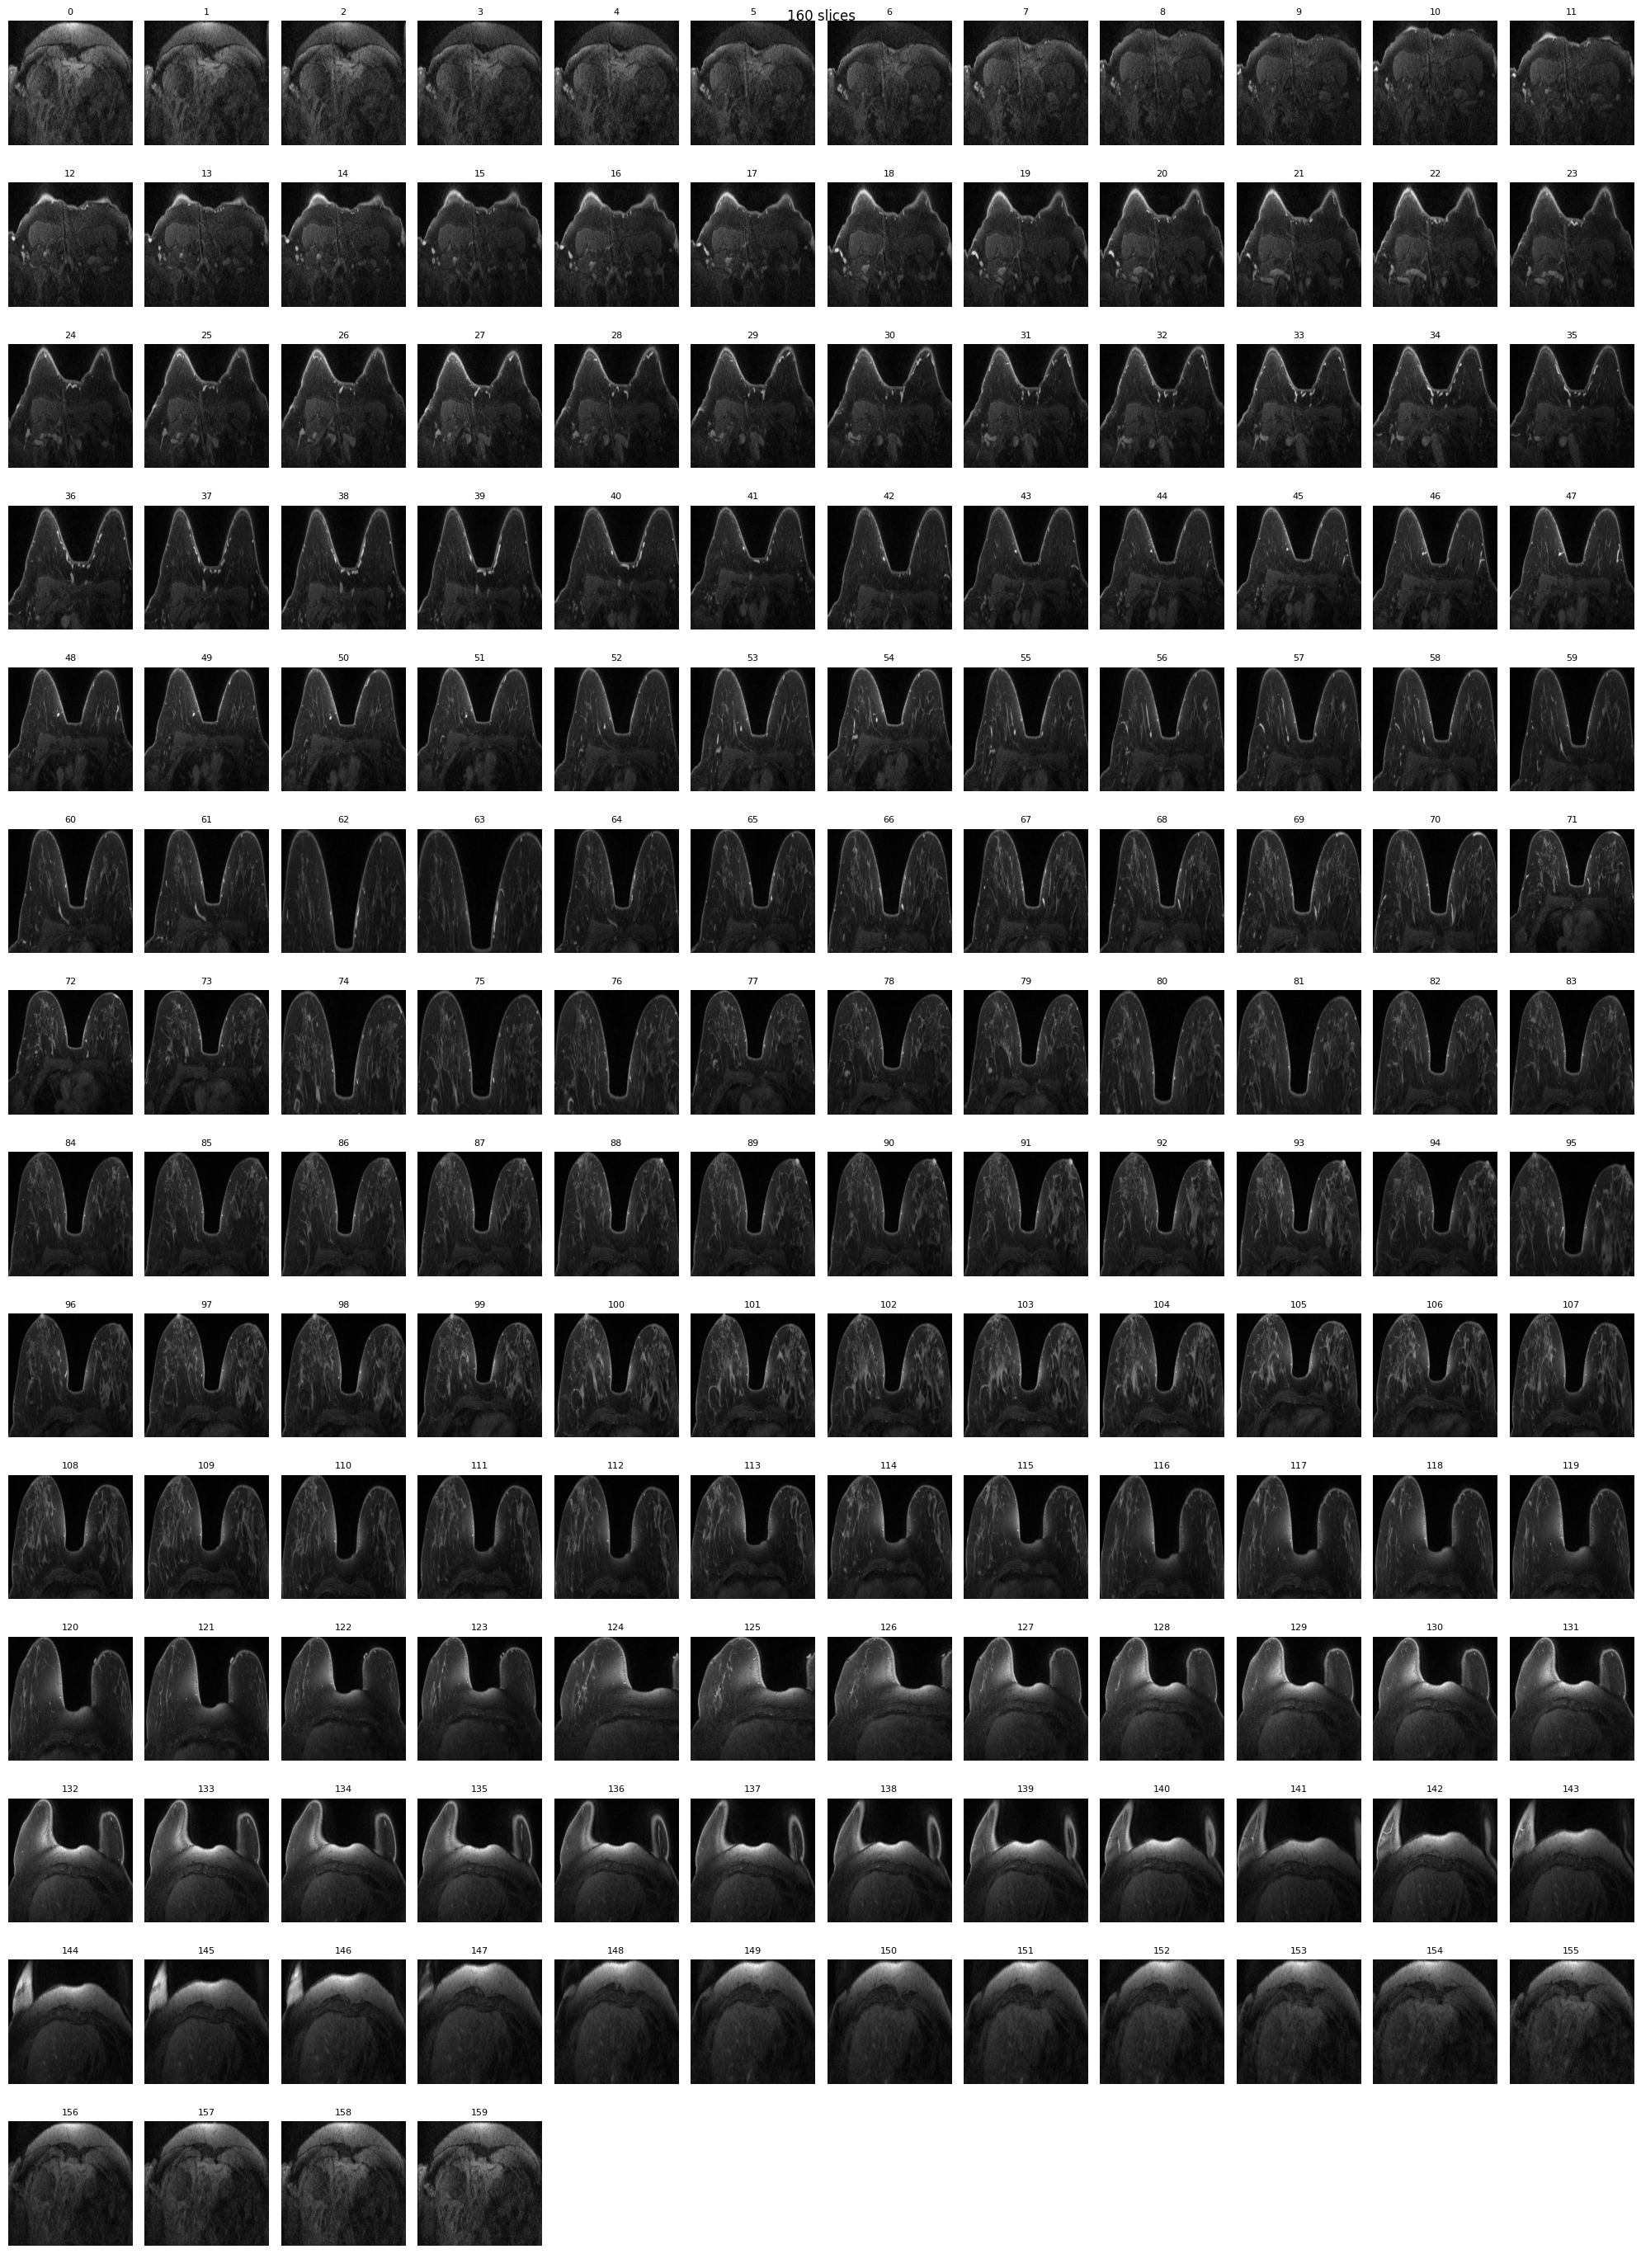

In [158]:
n_slices = len(sequence)
n_cols = 12  
n_rows = int(np.ceil(n_slices / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*2))
axes = axes.flatten()

for i in range(len(axes)):
    if i < n_slices:
        axes[i].imshow(sequence[i], cmap='gray')
        axes[i].set_title(f'{i}', fontsize=8)
    axes[i].axis('off')
    
plt.suptitle(f'{n_slices} slices')
plt.tight_layout()
plt.show()